# Train–Evaluation–Test Modeling, XGBoost, and Imbalance Analysis

Project: Predicting Student Dropout Risk in Online Learning Platforms  
Dataset: Open University Learning Analytics Dataset (OULAD)

This notebook preserves the questions and conclusions of `checkpoint1_EDA_v1.ipynb` while
adding a leakage-controlled 70% training / 15% evaluation / 15% test workflow, XGBoost,
evaluation-only model and imbalance selection, and one final untouched-test report.

Target definition:

```text
final_result == "Withdrawn" -> target_dropout = 1
Pass / Fail / Distinction -> target_dropout = 0
```

Prediction timing:

```text
Only data available by 25% of each module presentation is used.
```

In [1]:
# Dependency check
import importlib.util
import sys
from pathlib import Path

required_core = ["pandas", "numpy"]
optional = ["matplotlib", "seaborn", "sklearn"]

availability = {pkg: importlib.util.find_spec(pkg) is not None for pkg in required_core + optional}
print("Package availability:")
print(availability)

missing_core = [pkg for pkg in required_core if not availability[pkg]]
if missing_core:
    raise ImportError(f"Missing required packages: {missing_core}")

missing_optional = [pkg for pkg in optional if not availability[pkg]]
if missing_optional:
    print("\nOptional packages missing:", missing_optional)
    print("Install them in the active notebook environment if you want plots/model training:")
    print(f"{sys.executable} -m pip install matplotlib seaborn scikit-learn")


Package availability:
{'pandas': True, 'numpy': True, 'matplotlib': True, 'seaborn': True, 'sklearn': True}


In [2]:
import warnings
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

DATA_DIR = Path("open+university+learning+analytics+dataset")
assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR.resolve()}"

def read_csv(name):
    return pd.read_csv(DATA_DIR / name, na_values=["?"])

assessments = read_csv("assessments.csv")
courses = read_csv("courses.csv")
student_assessment = read_csv("studentAssessment.csv")
student_info = read_csv("studentInfo.csv")
student_registration = read_csv("studentRegistration.csv")
vle = read_csv("vle.csv")

KEY = ["code_module", "code_presentation", "id_student"]
COURSE_KEY = ["code_module", "code_presentation"]

print("Loaded files:")
for name, df in {
    "assessments": assessments,
    "courses": courses,
    "student_assessment": student_assessment,
    "student_info": student_info,
    "student_registration": student_registration,
    "vle": vle,
}.items():
    print(f"{name:22s} {df.shape}")


Loaded files:
assessments            (206, 6)
courses                (22, 3)
student_assessment     (173912, 5)
student_info           (32593, 12)
student_registration   (32593, 5)
vle                    (6364, 6)


## 1. Relational Dataset Structure

OULAD is not a single flat file. The final model must be built by joining and aggregating multiple tables.

Main modeling unit:

```text
code_module + code_presentation + id_student
```

Lookup/reference keys:

- `courses.csv`: `code_module + code_presentation`
- `assessments.csv`: `id_assessment`, plus course keys
- `vle.csv`: `id_site + code_module + code_presentation`

Many-to-one tables:

- `studentAssessment.csv`: many assessment rows per student-course
- `studentVle.csv`: many clickstream rows per student-course


In [3]:
def summarize_df(df, name):
    return pd.Series({
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "missing_cells": int(df.isna().sum().sum()),
    }, name=name)

summary = pd.DataFrame([
    summarize_df(assessments, "assessments"),
    summarize_df(courses, "courses"),
    summarize_df(student_assessment, "studentAssessment"),
    summarize_df(student_info, "studentInfo"),
    summarize_df(student_registration, "studentRegistration"),
    summarize_df(vle, "vle"),
])
summary


,rows,columns,duplicate_rows,missing_cells
assessments,206,6,0,11
courses,22,3,0,0
studentAssessment,173912,5,0,173
studentInfo,32593,12,0,1111
studentRegistration,32593,5,0,22566
vle,6364,6,0,10486


In [4]:
print("Missing values by table:")
for name, df in {
    "assessments": assessments,
    "courses": courses,
    "studentAssessment": student_assessment,
    "studentInfo": student_info,
    "studentRegistration": student_registration,
    "vle": vle,
}.items():
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{name}")
    print(miss if len(miss) else "No missing values")


Missing values by table:

assessments
date    11
dtype: int64

courses
No missing values

studentAssessment
score    173
dtype: int64

studentInfo
imd_band    1111
dtype: int64

studentRegistration
date_unregistration    22521
date_registration         45
dtype: int64

vle
week_from    5243
week_to      5243
dtype: int64


## 2. Target Variable and 25% Checkpoint

The base table starts from `studentInfo.csv`. We add:

- `target_dropout`
- module presentation length
- checkpoint day at 25% of course length

This checkpoint is the leakage boundary. VLE rows and assessment evidence after this day must not be used.


In [5]:
base = student_info.copy()
base["target_dropout"] = (base["final_result"] == "Withdrawn").astype(int)

base = base.merge(courses, on=COURSE_KEY, how="left")
base["checkpoint_day"] = np.floor(base["module_presentation_length"] * 0.25).astype(int)

print("Base shape:", base.shape)
print("\nFinal result distribution:")
display(base["final_result"].value_counts())
print("\nBinary target distribution:")
display(base["target_dropout"].value_counts().rename(index={0: "not_withdrawn", 1: "withdrawn"}))
print("\nDropout rate:", round(base["target_dropout"].mean(), 4))
base.head()


Base shape: (32593, 15)

Final result distribution:


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


Binary target distribution:


target_dropout
not_withdrawn    22437
withdrawn        10156
Name: count, dtype: int64


Dropout rate: 0.3116


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target_dropout,module_presentation_length,checkpoint_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,268,67
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,268,67
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,268,67
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,268,67
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,268,67


## 3. Extended EDA: Candidate Features vs Dropout

This section checks how the available pre-course/static variables relate to withdrawal.

They are screening views to guide feature engineering and fairness checks.


In [6]:
def dropout_rate_table(df, col, min_count=25):
    out = (
        df.groupby(col, dropna=False)
        .agg(
            records=("target_dropout", "size"),
            dropout_rate=("target_dropout", "mean"),
            withdrawn=("target_dropout", "sum"),
        )
        .reset_index()
        .sort_values("dropout_rate", ascending=False)
    )
    return out[out["records"] >= min_count]

categorical_cols = [
    "code_module", "code_presentation", "gender", "region", "highest_education",
    "imd_band", "age_band", "disability"
]

for col in categorical_cols:
    print(f"\nDropout rate by {col}")
    display(dropout_rate_table(base, col).head(20))



Dropout rate by code_module


,code_module,records,dropout_rate,withdrawn
2,CCC,4434,0.445422,1975
3,DDD,6272,0.358737,2250
5,FFF,7762,0.309585,2403
1,BBB,7909,0.301935,2388
4,EEE,2934,0.246080,722
0,AAA,748,0.168449,126
6,GGG,2534,0.115233,292



Dropout rate by code_presentation


,code_presentation,records,dropout_rate,withdrawn
3,2014J,11260,0.339787,3826
2,2014B,7804,0.334828,2613
0,2013B,4684,0.287788,1348
1,2013J,8845,0.267835,2369



Dropout rate by gender


...

,imd_band,records,dropout_rate,withdrawn
0,0-10%,3311,0.371791,1231
2,20-30%,3654,0.361522,1321
1,10-20,3516,0.354380,1246
4,40-50%,3256,0.320025,1042
3,30-40%,3539,0.309409,1095
6,60-70%,2905,0.295697,859
5,50-60%,3124,0.287772,899
8,80-90%,2762,0.280232,774
7,70-80%,2879,0.276832,797
9,90-100%,2536,0.258675,656



Dropout rate by age_band


,age_band,records,dropout_rate,withdrawn
0,0-35,22944,0.321696,7381
1,35-55,9433,0.288455,2721
2,55<=,216,0.250000,54



Dropout rate by disability


,disability,records,dropout_rate,withdrawn
1,Y,3164,0.393489,1245
0,N,29429,0.302797,8911


In [7]:
numeric_screen_cols = [
    "num_of_prev_attempts", "studied_credits",
    "module_presentation_length", "checkpoint_day"
]

print("Numeric feature summaries by target:")
display(base.groupby("target_dropout")[numeric_screen_cols].agg(["count", "mean", "median", "std"]).T)

print("\nCorrelation with target_dropout:")
display(base[numeric_screen_cols + ["target_dropout"]].corr(numeric_only=True)["target_dropout"].sort_values(ascending=False))


Numeric feature summaries by target:


target_dropout                                0             1
num_of_prev_attempts       count   22437.000000  10156.000000
                           mean        0.152605      0.186688
                           median      0.000000      0.000000
                           std         0.463091      0.513917
studied_credits            count   22437.000000  10156.000000
                           mean       74.475643     91.430189
                           median     60.000000     60.000000
                           std        36.811006     47.141690
module_presentation_length count   22437.000000  10156.000000
                           mean      256.060525    255.898779
                           median    262.000000    262.000000
                           std        13.163521     13.213350
checkpoint_day             count   22437.000000  10156.000000
                           mean       63.807996     63.751378
                           median     65.000000     65.000000
                           std         3.301288      3.308513


Correlation with target_dropout:


target_dropout                1.000000
studied_credits               0.191191
num_of_prev_attempts          0.032903
module_presentation_length   -0.005684
checkpoint_day               -0.007938
Name: target_dropout, dtype: float64

## 4. Registration Feature Engineering

Use `date_registration` because it is known before/near course start.

Do not use `date_unregistration` as a predictor. It directly reveals withdrawal timing and causes leakage.


In [8]:
registration_features = student_registration[KEY + ["date_registration"]].copy()
registration_features["registration_missing_flag"] = (
    registration_features["date_registration"].isna().astype(int)
)

# Do not impute here. The model pipeline learns its median from the training partition only.
registration_features["registered_before_start_days"] = (
    -registration_features["date_registration"]
).clip(lower=0)
registration_features["registered_after_start_flag"] = np.where(
    registration_features["date_registration"].isna(),
    0,
    (registration_features["date_registration"] > 0).astype(int),
)

print(
    "Registration dates deliberately left missing for train-only pipeline imputation:",
    int(registration_features["date_registration"].isna().sum()),
)
registration_features.head()

Registration dates deliberately left missing for train-only pipeline imputation: 45


,code_module,code_presentation,id_student,date_registration,registration_missing_flag,registered_before_start_days,registered_after_start_flag
0,AAA,2013J,11391,-159.0,0,159.0,0
1,AAA,2013J,28400,-53.0,0,53.0,0
2,AAA,2013J,30268,-92.0,0,92.0,0
3,AAA,2013J,31604,-52.0,0,52.0,0
4,AAA,2013J,32885,-176.0,0,176.0,0


## 5. VLE Feature Engineering up to 25% Checkpoint

The VLE table is large, so the feature generation below reads `studentVle.csv` in chunks.

Features produced:

- total early clicks
- number of VLE log rows/events
- active days
- distinct resources
- last activity day before checkpoint
- days since last activity at checkpoint
- click totals by major activity type


In [9]:
checkpoint_lookup = base[KEY + ["checkpoint_day"]].copy()
vle_meta = vle[["id_site", "code_module", "code_presentation", "activity_type"]].copy()

top_activity_types = (
    vle["activity_type"]
    .value_counts(dropna=False)
    .head(12)
    .index
    .tolist()
)
print("Top activity types retained:", top_activity_types)

event_parts = []
last_activity_parts = []
active_day_parts = []
distinct_site_parts = []
activity_parts = []

student_vle_path = DATA_DIR / "studentVle.csv"
usecols = ["code_module", "code_presentation", "id_student", "id_site", "date", "sum_click"]

for chunk in pd.read_csv(student_vle_path, usecols=usecols, chunksize=1_000_000):
    chunk = chunk.merge(checkpoint_lookup, on=KEY, how="inner")
    chunk = chunk[chunk["date"] <= chunk["checkpoint_day"]]
    if chunk.empty:
        continue

    event_agg = (
        chunk.groupby(KEY)
        .agg(
            total_clicks_25pct=("sum_click", "sum"),
            vle_events_25pct=("sum_click", "size"),
        )
        .reset_index()
    )
    event_parts.append(event_agg)

    last_activity_parts.append(
        chunk.groupby(KEY, as_index=False)["date"]
        .max()
        .rename(columns={"date": "last_activity_day_25pct"})
    )
    active_day_parts.append(chunk[KEY + ["date"]].drop_duplicates())
    distinct_site_parts.append(chunk[KEY + ["id_site"]].drop_duplicates())

    chunk = chunk.merge(vle_meta, on=["id_site", "code_module", "code_presentation"], how="left")
    chunk["activity_type"] = chunk["activity_type"].where(
        chunk["activity_type"].isin(top_activity_types), "other_activity"
    )
    activity_agg = (
        chunk.groupby(KEY + ["activity_type"])["sum_click"]
        .sum()
        .reset_index()
        .pivot_table(index=KEY, columns="activity_type", values="sum_click", fill_value=0)
        .reset_index()
    )
    activity_parts.append(activity_agg)

vle_events = pd.concat(event_parts, ignore_index=True).groupby(KEY, as_index=False).sum()
vle_last_activity = pd.concat(last_activity_parts, ignore_index=True).groupby(KEY, as_index=False).max()
vle_active_days = (
    pd.concat(active_day_parts, ignore_index=True)
    .drop_duplicates()
    .groupby(KEY)
    .size()
    .reset_index(name="active_days_25pct")
)
vle_distinct_sites = (
    pd.concat(distinct_site_parts, ignore_index=True)
    .drop_duplicates()
    .groupby(KEY)
    .size()
    .reset_index(name="distinct_sites_25pct")
)
vle_base = (
    vle_events
    .merge(vle_active_days, on=KEY, how="left")
    .merge(vle_distinct_sites, on=KEY, how="left")
    .merge(vle_last_activity, on=KEY, how="left")
)
vle_activity = pd.concat(activity_parts, ignore_index=True).groupby(KEY, as_index=False).sum()

vle_features = vle_base.merge(vle_activity, on=KEY, how="left")
vle_features = vle_features.merge(checkpoint_lookup, on=KEY, how="left")
vle_features["days_since_last_activity_at_checkpoint"] = (
    vle_features["checkpoint_day"] - vle_features["last_activity_day_25pct"]
)
vle_features = vle_features.drop(columns=["checkpoint_day"])

rename_map = {
    col: f"clicks_{str(col).replace('-', '_').replace(' ', '_')}_25pct"
    for col in vle_activity.columns
    if col not in KEY
}
vle_features = vle_features.rename(columns=rename_map)

print("VLE features shape:", vle_features.shape)
vle_features.head()


Top activity types retained: ['resource', 'subpage', 'oucontent', 'url', 'forumng', 'quiz', 'page', 'oucollaborate', 'questionnaire', 'ouwiki', 'dataplus', 'externalquiz']


VLE features shape: (29119, 22)


,code_module,code_presentation,id_student,total_clicks_25pct,vle_events_25pct,active_days_25pct,distinct_sites_25pct,last_activity_day_25pct,clicks_dataplus_25pct,clicks_forumng_25pct,...,clicks_oucontent_25pct,clicks_quiz_25pct,clicks_resource_25pct,clicks_subpage_25pct,clicks_url_25pct,clicks_externalquiz_25pct,clicks_ouwiki_25pct,clicks_page_25pct,clicks_questionnaire_25pct,days_since_last_activity_at_checkpoint
0,AAA,2013J,11391,545,92,19,34,65,0.0,98.0,...,344.0,0.0,9.0,23.0,1.0,0.0,0.0,0.0,0.0,2
1,AAA,2013J,28400,723,201,29,38,64,0.0,254.0,...,209.0,0.0,5.0,62.0,33.0,0.0,0.0,0.0,0.0,3
2,AAA,2013J,30268,281,76,12,22,12,0.0,126.0,...,66.0,0.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,55
3,AAA,2013J,31604,879,259,43,42,67,0.0,234.0,...,328.0,0.0,10.0,78.0,39.0,0.0,0.0,0.0,0.0,0
4,AAA,2013J,32885,608,163,29,35,67,0.0,138.0,...,315.0,0.0,7.0,29.0,6.0,0.0,0.0,0.0,0.0,0


## 6. Assessment Feature Engineering up to 25% Checkpoint

Use only assessments due by the checkpoint and submissions made by the checkpoint.

Students who have an early assessment due but no submission by the checkpoint get counted as missing for that early assessment.


In [10]:
assessment_defs = assessments.merge(
    courses.assign(checkpoint_day=np.floor(courses["module_presentation_length"] * 0.25).astype(int)),
    on=COURSE_KEY,
    how="left"
)
assessment_defs["date_missing_flag"] = assessment_defs["date"].isna().astype(int)
early_defs = assessment_defs[
    assessment_defs["date"].notna() & (assessment_defs["date"] <= assessment_defs["checkpoint_day"])
].copy()

early_due = (
    early_defs.groupby(COURSE_KEY)
    .agg(
        early_assessments_due_count=("id_assessment", "nunique"),
        early_assessment_weight_total=("weight", "sum"),
    )
    .reset_index()
)

early_submissions = student_assessment.merge(
    early_defs[["id_assessment", "code_module", "code_presentation", "assessment_type", "date", "weight", "checkpoint_day"]],
    on="id_assessment",
    how="inner"
)
early_submissions = early_submissions[early_submissions["date_submitted"] <= early_submissions["checkpoint_day"]].copy()
early_submissions["submission_delay"] = early_submissions["date_submitted"] - early_submissions["date"]
early_submissions["late_submission_flag"] = (early_submissions["submission_delay"] > 0).astype(int)
early_submissions["weighted_score_component"] = early_submissions["score"] * early_submissions["weight"]

assessment_features = (
    early_submissions.groupby(KEY)
    .agg(
        early_assessments_submitted_count=("id_assessment", "nunique"),
        mean_early_score=("score", "mean"),
        min_early_score=("score", "min"),
        max_early_score=("score", "max"),
        early_score_missing_count=("score", lambda s: s.isna().sum()),
        weighted_early_score_num=("weighted_score_component", "sum"),
        submitted_early_weight_total=("weight", "sum"),
        average_submission_delay=("submission_delay", "mean"),
        late_submission_count=("late_submission_flag", "sum"),
        banked_assessment_count=("is_banked", "sum"),
    )
    .reset_index()
)
assessment_features["weighted_early_score"] = np.where(
    assessment_features["submitted_early_weight_total"] > 0,
    assessment_features["weighted_early_score_num"] / assessment_features["submitted_early_weight_total"],
    np.nan,
)
assessment_features = assessment_features.drop(columns=["weighted_early_score_num"])

assessment_features = assessment_features.merge(base[KEY].drop_duplicates(), on=KEY, how="right")
assessment_features = assessment_features.merge(early_due, on=COURSE_KEY, how="left")
assessment_features["early_assessments_due_count"] = assessment_features["early_assessments_due_count"].fillna(0)
assessment_features["early_assessment_weight_total"] = assessment_features["early_assessment_weight_total"].fillna(0)
assessment_features["early_assessments_submitted_count"] = assessment_features["early_assessments_submitted_count"].fillna(0)
assessment_features["early_assessments_missing_count"] = (
    assessment_features["early_assessments_due_count"] - assessment_features["early_assessments_submitted_count"]
).clip(lower=0)

print("Assessment features shape:", assessment_features.shape)
assessment_features.head()


Assessment features shape: (32593, 16)


,code_module,code_presentation,id_student,early_assessments_submitted_count,mean_early_score,min_early_score,max_early_score,early_score_missing_count,submitted_early_weight_total,average_submission_delay,late_submission_count,banked_assessment_count,weighted_early_score,early_assessments_due_count,early_assessment_weight_total,early_assessments_missing_count
0,AAA,2013J,11391,2.0,81.5,78.0,85.0,0.0,30.0,-1.0,0.0,0.0,82.666667,2.0,30.0,0.0
1,AAA,2013J,28400,2.0,69.0,68.0,70.0,0.0,30.0,0.5,1.0,0.0,68.666667,2.0,30.0,0.0
2,AAA,2013J,30268,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.0,2.0
3,AAA,2013J,31604,2.0,71.5,71.0,72.0,0.0,30.0,-2.5,0.0,0.0,71.333333,2.0,30.0,0.0
4,AAA,2013J,32885,1.0,69.0,69.0,69.0,0.0,10.0,7.0,1.0,0.0,69.000000,2.0,30.0,1.0


## 7. Final Modeling Dataset

This is the dataset to use for Checkpoint 1 baseline modeling.

One row = one student-course enrollment.


In [11]:
profile_cols = [
    "code_module", "code_presentation", "id_student",
    "gender", "region", "highest_education", "imd_band", "age_band",
    "num_of_prev_attempts", "studied_credits", "disability",
    "module_presentation_length", "checkpoint_day", "target_dropout"
]

final_modeling_dataset = base[profile_cols].copy()
final_modeling_dataset["imd_band"] = final_modeling_dataset["imd_band"].fillna("Unknown")

final_modeling_dataset = final_modeling_dataset.merge(registration_features, on=KEY, how="left")
final_modeling_dataset = final_modeling_dataset.merge(vle_features, on=KEY, how="left")
final_modeling_dataset = final_modeling_dataset.merge(assessment_features, on=KEY, how="left")

# Preserve the difference between no VLE activity and activity on the checkpoint day.
final_modeling_dataset["no_early_vle_activity_flag"] = (
    final_modeling_dataset["last_activity_day_25pct"].isna().astype(int)
)

# Missing count values after a left join mean that no such early event was recorded.
# Recency and score values are intentionally NOT filled here; the training-only pipeline
# will learn their imputation values.
zero_fill_prefixes = [
    "total_clicks", "vle_events", "active_days", "distinct_sites",
    "clicks_", "early_assessments", "late_submission", "banked_assessment",
    "early_score_missing", "early_assessment_weight", "submitted_early_weight"
]
for col in final_modeling_dataset.columns:
    if any(col.startswith(prefix) for prefix in zero_fill_prefixes):
        final_modeling_dataset[col] = final_modeling_dataset[col].fillna(0)

score_or_timing_features = [
    "mean_early_score", "min_early_score", "max_early_score",
    "weighted_early_score", "average_submission_delay"
]
for col in score_or_timing_features:
    if col in final_modeling_dataset.columns:
        final_modeling_dataset[f"{col}_missing_flag"] = (
            final_modeling_dataset[col].isna().astype(int)
        )

print("Final modeling dataset shape:", final_modeling_dataset.shape)
print("Duplicate modeling keys:", final_modeling_dataset.duplicated(KEY).sum())
print("\nTarget distribution:")
display(final_modeling_dataset["target_dropout"].value_counts())
print("\nMissing values retained for train-only imputation:")
display(final_modeling_dataset.isna().sum().sort_values(ascending=False).head(20))
final_modeling_dataset.head()

Final modeling dataset shape: (32593, 56)
Duplicate modeling keys: 0

Target distribution:


target_dropout
0    22437
1    10156
Name: count, dtype: int64


Missing values retained for train-only imputation:


weighted_early_score                      9234
mean_early_score                          7727
min_early_score                           7727
max_early_score                           7727
average_submission_delay                  7706
days_since_last_activity_at_checkpoint    3474
last_activity_day_25pct                   3474
date_registration                           45
registered_before_start_days                45
clicks_externalquiz_25pct                    0
clicks_ouwiki_25pct                          0
clicks_page_25pct                            0
clicks_questionnaire_25pct                   0
early_assessments_submitted_count            0
early_score_missing_count                    0
code_module                                  0
submitted_early_weight_total                 0
clicks_subpage_25pct                         0
late_submission_count                        0
banked_assessment_count                      0
dtype: int64

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,weighted_early_score,early_assessments_due_count,early_assessment_weight_total,early_assessments_missing_count,no_early_vle_activity_flag,mean_early_score_missing_flag,min_early_score_missing_flag,max_early_score_missing_flag,weighted_early_score_missing_flag,average_submission_delay_missing_flag
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,82.666667,2.0,30.0,0.0,0,0,0,0,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,68.666667,2.0,30.0,0.0,0,0,0,0,0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,2.0,30.0,2.0,0,1,1,1,1,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,71.333333,2.0,30.0,0.0,0,0,0,0,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,69.000000,2.0,30.0,1.0,0,0,0,0,0,0


In [12]:
numeric_features = final_modeling_dataset.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c not in ["id_student", "target_dropout"]]

categorical_features = [
    c for c in final_modeling_dataset.select_dtypes(include=["object"]).columns
    if c not in []
]

excluded_from_model = [
    "id_student",          # identifier only
    "target_dropout",     # target
    "final_result",        # original target; not in final dataset
    "date_unregistration", # leakage; not in final dataset
]

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))
print("\nNumeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)
print("\nExplicitly excluded:")
print(excluded_from_model)


Numeric feature count: 46
Categorical feature count: 8

Numeric features:
['num_of_prev_attempts', 'studied_credits', 'module_presentation_length', 'checkpoint_day', 'date_registration', 'registration_missing_flag', 'registered_before_start_days', 'registered_after_start_flag', 'total_clicks_25pct', 'vle_events_25pct', 'active_days_25pct', 'distinct_sites_25pct', 'last_activity_day_25pct', 'clicks_dataplus_25pct', 'clicks_forumng_25pct', 'clicks_other_activity_25pct', 'clicks_oucollaborate_25pct', 'clicks_oucontent_25pct', 'clicks_quiz_25pct', 'clicks_resource_25pct', 'clicks_subpage_25pct', 'clicks_url_25pct', 'clicks_externalquiz_25pct', 'clicks_ouwiki_25pct', 'clicks_page_25pct', 'clicks_questionnaire_25pct', 'days_since_last_activity_at_checkpoint', 'early_assessments_submitted_count', 'mean_early_score', 'min_early_score', 'max_early_score', 'early_score_missing_count', 'submitted_early_weight_total', 'average_submission_delay', 'late_submission_count', 'banked_assessment_count', 

## 8. Correlation and Feature-Target Association

For numeric features, correlation with `target_dropout` gives a quick directional screen.

For categorical features, dropout-rate tables are usually more interpretable than raw correlation.


In [13]:
numeric_corr = (
    final_modeling_dataset[numeric_features + ["target_dropout"]]
    .corr(numeric_only=True)["target_dropout"]
    .drop("target_dropout")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Top numeric associations with target_dropout:")
display(numeric_corr.head(25))

for col in categorical_features:
    print(f"\nDropout rate by {col}")
    display(dropout_rate_table(final_modeling_dataset, col).head(15))


Top numeric associations with target_dropout:


early_assessments_missing_count           0.562966
max_early_score_missing_flag              0.494909
min_early_score_missing_flag              0.494909
mean_early_score_missing_flag             0.494909
average_submission_delay_missing_flag     0.493743
days_since_last_activity_at_checkpoint    0.457640
early_assessments_submitted_count        -0.453045
last_activity_day_25pct                  -0.452113
submitted_early_weight_total             -0.440965
weighted_early_score_missing_flag         0.424970
no_early_vle_activity_flag                0.413567
active_days_25pct                        -0.375543
vle_events_25pct                         -0.313722
distinct_sites_25pct                     -0.310343
max_early_score                          -0.271844
weighted_early_score                     -0.265988
total_clicks_25pct                       -0.260140
mean_early_score                         -0.241133
clicks_other_activity_25pct              -0.236836
clicks_oucontent_25pct         


Dropout rate by code_module


,code_module,records,dropout_rate,withdrawn
2,CCC,4434,0.445422,1975
3,DDD,6272,0.358737,2250
5,FFF,7762,0.309585,2403
1,BBB,7909,0.301935,2388
4,EEE,2934,0.246080,722
0,AAA,748,0.168449,126
6,GGG,2534,0.115233,292



Dropout rate by code_presentation


...

,imd_band,records,dropout_rate,withdrawn
0,0-10%,3311,0.371791,1231
2,20-30%,3654,0.361522,1321
1,10-20,3516,0.354380,1246
4,40-50%,3256,0.320025,1042
3,30-40%,3539,0.309409,1095
6,60-70%,2905,0.295697,859
5,50-60%,3124,0.287772,899
8,80-90%,2762,0.280232,774
7,70-80%,2879,0.276832,797
9,90-100%,2536,0.258675,656



Dropout rate by age_band


,age_band,records,dropout_rate,withdrawn
0,0-35,22944,0.321696,7381
1,35-55,9433,0.288455,2721
2,55<=,216,0.250000,54



Dropout rate by disability


,disability,records,dropout_rate,withdrawn
1,Y,3164,0.393489,1245
0,N,29429,0.302797,8911


## 9. Feature Decision: Columns to Use

Recommended feature groups:

1. Student profile: demographics, prior attempts, studied credits.
2. Registration timing: registration day, before/after start flags.
3. Course context: module, presentation, course length, checkpoint day.
4. Early VLE engagement: clicks, active days, resource breadth, activity-type clicks.
5. Early assessment behavior: submitted/missing counts, scores, delays, banked assessments.

Columns excluded because of leakage or identifier-only use:

- `final_result`
- `date_unregistration`
- post-checkpoint VLE activity
- post-checkpoint assessment submissions/scores
- `id_student` as a model input


## 10. Leakage-Safe Three-Way Split and Model Comparison

The reference preprocessing notebook uses a **70% training / 15% evaluation / 15% test**
design. This notebook uses the same proportions and adds a student-level grouping safeguard:
all enrollments belonging to one `id_student` stay in exactly one partition.

Partition roles are fixed before modeling:

| Partition | Permitted use |
|---|---|
| Training | Fit preprocessing, model parameters, sample weights, and resampling methods |
| Evaluation | Compare Logistic Regression, Random Forest, HistGradientBoosting, and XGBoost; compare imbalance strategies and weights |
| Test | One final report after the model family and imbalance treatment are fixed |

Candidate models:

- **Logistic Regression:** interpretable linear baseline.
- **Random Forest:** independently trained, averaged decision trees.
- **HistGradientBoosting:** sequential histogram-based trees that correct earlier errors.
- **XGBoost:** regularized gradient-boosted trees, included as an additional tabular benchmark.

PR-AUC is the primary ranking metric. Differences below `0.005` are treated as practically
tied; F1, withdrawal recall, and ROC-AUC then break the tie. This prevents a negligible
PR-AUC difference from overriding a consistently better result on the other metrics. The
test labels are not used for candidate or weight selection.

### 10.1 XGBoost primer

XGBoost is also a gradient-boosted tree method: trees are added sequentially to reduce
the remaining classification loss. Compared with scikit-learn HistGradientBoosting, it
adds explicit tree regularization plus row and column subsampling controls. This can improve
generalization, but it also introduces an external dependency and more parameters.

Both use binary log loss and balanced sample weights in this comparison. XGBoost is included
as an additional benchmark, not assumed to be better in advance. The evaluation evidence—not
the algorithm's popularity—decides whether it proceeds.


In [14]:
if not availability.get("sklearn", False):
    raise ImportError("scikit-learn is required for the model comparison.")

import importlib.util
if importlib.util.find_spec("xgboost") is None:
    raise ImportError(
        "XGBoost is required for this comparison. Install it with: "
        "python -m pip install xgboost"
    )

from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

X = final_modeling_dataset[numeric_features + categorical_features].copy()
y = final_modeling_dataset["target_dropout"].copy()
student_groups = final_modeling_dataset["id_student"].copy()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

# Twenty group-stratified folds allow an exact 14/3/3 fold allocation: 70%/15%/15%.
# Grouping prevents the same student from appearing in more than one partition.
splitter = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=42)
fold_assignment = np.full(len(X), -1, dtype=int)
for fold_number, (_, fold_indices) in enumerate(
    splitter.split(X, y, groups=student_groups)
):
    fold_assignment[fold_indices] = fold_number

assert (fold_assignment >= 0).all()
test_mask = np.isin(fold_assignment, [0, 1, 2])
eval_mask = np.isin(fold_assignment, [3, 4, 5])
train_mask = ~(test_mask | eval_mask)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_eval, y_eval = X.loc[eval_mask].copy(), y.loc[eval_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()
groups_train = student_groups.loc[train_mask]
groups_eval = student_groups.loc[eval_mask]
groups_test = student_groups.loc[test_mask]

assert set(groups_train).isdisjoint(set(groups_eval))
assert set(groups_train).isdisjoint(set(groups_test))
assert set(groups_eval).isdisjoint(set(groups_test))
assert len(X_train) + len(X_eval) + len(X_test) == len(X)

split_audit_df = pd.DataFrame([
    {
        "partition": name,
        "rows": len(target),
        "row_percent": len(target) / len(y),
        "unique_students": groups.nunique(),
        "not_withdrawn": int((target == 0).sum()),
        "withdrawn": int((target == 1).sum()),
        "withdrawal_prevalence": float(target.mean()),
    }
    for name, target, groups in [
        ("Training", y_train, groups_train),
        ("Evaluation", y_eval, groups_eval),
        ("Test", y_test, groups_test),
    ]
])
display(split_audit_df.style.format({
    "row_percent": "{:.1%}",
    "withdrawal_prevalence": "{:.3f}",
}))
print("Student overlap across partitions: 0 (asserted).")

training_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

candidate_models = {
    "LogisticRegression_balanced": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
    ),
    "RandomForest_balanced": RandomForestClassifier(
        n_estimators=250,
        random_state=42,
        n_jobs=1,
        class_weight="balanced_subsample",
    ),
    "HistGradientBoosting_weighted": HistGradientBoostingClassifier(
        loss="log_loss",
        random_state=42,
        learning_rate=0.08,
        max_iter=200,
    ),
    "XGBoost_weighted": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=1,
    ),
}


def metric_row(model_name, actual, probability, threshold=0.5):
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, prediction, labels=[0, 1]).ravel()
    return {
        "model": model_name,
        "accuracy": accuracy_score(actual, prediction),
        "balanced_accuracy": balanced_accuracy_score(actual, prediction),
        "roc_auc": roc_auc_score(actual, probability),
        "pr_auc": average_precision_score(actual, probability),
        "precision_at_0_5": precision_score(actual, prediction, zero_division=0),
        "recall_at_0_5": recall_score(actual, prediction, zero_division=0),
        "f1_at_0_5": f1_score(actual, prediction, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


evaluation_rows = []
fitted_models = {}
evaluation_predictions = {}
for name, model in candidate_models.items():
    pipe = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", clone(model)),
    ])
    fit_kwargs = {}
    if name in {"HistGradientBoosting_weighted", "XGBoost_weighted"}:
        fit_kwargs["model__sample_weight"] = training_sample_weight
    pipe.fit(X_train, y_train, **fit_kwargs)
    probability = pipe.predict_proba(X_eval)[:, 1]
    evaluation_rows.append(metric_row(name, y_eval, probability))
    fitted_models[name] = pipe
    evaluation_predictions[name] = probability

results_df = pd.DataFrame(evaluation_rows).sort_values(
    ["pr_auc", "f1_at_0_5", "recall_at_0_5"],
    ascending=False,
).reset_index(drop=True)
display(results_df.style.format({
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
    "precision_at_0_5": "{:.3f}",
    "recall_at_0_5": "{:.3f}",
    "f1_at_0_5": "{:.3f}",
}))

# Treat PR-AUC differences below 0.005 as practically tied, then prefer the
# stronger thresholded balance (F1), withdrawal recall, and ROC-AUC.
best_pr_auc = float(results_df["pr_auc"].max())
practical_pr_ties = results_df[
    results_df["pr_auc"] >= best_pr_auc - 0.005
].sort_values(
    ["f1_at_0_5", "recall_at_0_5", "roc_auc", "precision_at_0_5"],
    ascending=False,
)
best_eval_name = practical_pr_ties.iloc[0]["model"]
print("Models within 0.005 of the best evaluation PR-AUC:")
display(practical_pr_ties[[
    "model", "pr_auc", "f1_at_0_5", "recall_at_0_5", "roc_auc"
]].style.format({
    "pr_auc": "{:.4f}",
    "f1_at_0_5": "{:.4f}",
    "recall_at_0_5": "{:.4f}",
    "roc_auc": "{:.4f}",
}))

best_eval_probability = evaluation_predictions[best_eval_name]
best_eval_prediction = (best_eval_probability >= 0.5).astype(int)
print("Leading model on the evaluation partition:", best_eval_name)
print("Evaluation confusion matrix at threshold 0.5:")
print(confusion_matrix(y_eval, best_eval_prediction))
print(classification_report(
    y_eval,
    best_eval_prediction,
    target_names=["not_withdrawn", "withdrawn"],
))
print("The test partition has not been used for model selection.")

,partition,rows,row_percent,unique_students,not_withdrawn,withdrawn,withdrawal_prevalence
0,Training,22833,70.1%,20138,15692,7141,0.313
1,Evaluation,4864,14.9%,4317,3324,1540,0.317
2,Test,4896,15.0%,4330,3421,1475,0.301


Student overlap across partitions: 0 (asserted).


,model,accuracy,balanced_accuracy,roc_auc,pr_auc,precision_at_0_5,recall_at_0_5,f1_at_0_5,tn,fp,fn,tp
0,HistGradientBoosting_weighted,0.832,0.813,0.883,0.824,0.724,0.759,0.741,2879,445,371,1169
1,XGBoost_weighted,0.833,0.815,0.885,0.824,0.724,0.764,0.744,2875,449,363,1177
2,RandomForest_balanced,0.837,0.788,0.883,0.819,0.797,0.652,0.717,3069,255,536,1004
3,LogisticRegression_balanced,0.825,0.807,0.874,0.802,0.710,0.757,0.733,2847,477,374,1166


Models within 0.005 of the best evaluation PR-AUC:


,model,pr_auc,f1_at_0_5,recall_at_0_5,roc_auc
1,XGBoost_weighted,0.8244,0.7435,0.7643,0.8845
0,HistGradientBoosting_weighted,0.8244,0.7413,0.7591,0.8831


Leading model on the evaluation partition: XGBoost_weighted
Evaluation confusion matrix at threshold 0.5:
[[2875  449]
 [ 363 1177]]
               precision    recall  f1-score   support

not_withdrawn       0.89      0.86      0.88      3324
    withdrawn       0.72      0.76      0.74      1540

     accuracy                           0.83      4864
    macro avg       0.81      0.81      0.81      4864
 weighted avg       0.84      0.83      0.83      4864

The test partition has not been used for model selection.


## 11. PCA Check Using Training Data Only

PCA is not automatically required. This probe is fitted only on the training partition.
The evaluation and test partitions are not used to learn encoding, scaling, or components.

Decision rule:

- Test PCA only as an optional Logistic Regression variant if encoded dimensionality is large.
- Do not apply PCA by default to tree-based models because it reduces interpretability.
- Explained predictor variance is not the same as predictive performance.

In [15]:
from sklearn.decomposition import PCA

training_preprocess_for_pca = clone(preprocess)
X_train_encoded = training_preprocess_for_pca.fit_transform(X_train)
print("Encoded training feature matrix shape:", X_train_encoded.shape)

if X_train_encoded.shape[1] <= 50:
    print("Feature count is modest. PCA is not required by default.")
else:
    pca_probe = PCA(n_components=0.95, random_state=42)
    pca_probe.fit(X_train_encoded)
    print("Original encoded feature count:", X_train_encoded.shape[1])
    print("Components needed for 95% training variance:", pca_probe.n_components_)
    print(
        "Recommendation: PCA may be tested for Logistic Regression inside validation, "
        "but the tree-based candidates retain the original encoded features."
    )

Encoded training feature matrix shape: (22833, 93)
Original encoded feature count: 93
Components needed for 95% training variance: 39
Recommendation: PCA may be tested for Logistic Regression inside validation, but the tree-based candidates retain the original encoded features.


## 12. Loss Function and Class Imbalance Recommendation

The positive class is `Withdrawn`. In this dataset, withdrawal is meaningful but not extremely rare.

Recommended loss/objective:

- Logistic Regression: binary cross-entropy, also called log loss.
- Tree/boosting classifiers: class-weighted split criteria or sample-weighted training where supported.

Recommended imbalance strategy:

- Use `class_weight="balanced"` for Logistic Regression and Random Forest.
- Use sample weights for HistGradientBoosting if chosen.
- Evaluate with ROC-AUC and PR-AUC.
- Report recall, precision, F1, and confusion matrix at the selected intervention threshold.

Why not accuracy alone?

Accuracy can look acceptable even when the model misses many withdrawn students. For this project, missing withdrawn students means missing opportunities for early support, so recall and PR-AUC are important.


## 13. Updated Conclusions After the Full Three-Way Evaluation

### 13.1 Modeling dataset and leakage controls

The feature questions and conclusions from the original notebook remain unchanged: early
assessment completion and early VLE engagement are the strongest withdrawal signals. The
new modeling table contains `32,593` enrollments, `46` numeric and `8` categorical predictors,
and an explicit `no_early_vle_activity_flag`.

The following controls prevent selection leakage:

- VLE and assessment evidence is restricted to the 25% checkpoint.
- Missing registration, score, timing, and recency values are retained until preprocessing.
- Preprocessing and imputation are fitted only on training data.
- All enrollments for the same student stay in one partition.
- Resampling and sample-weight construction use training data only.
- Model, augmentation, and weight decisions use evaluation data only.
- The test partition is scored once after the final candidate is frozen.

| Partition | Rows | Percentage | Unique students | Withdrawal prevalence |
|---|---:|---:|---:|---:|
| Training | 22,833 | 70.1% | 20,138 | 31.3% |
| Evaluation | 4,864 | 14.9% | 4,317 | 31.7% |
| Test | 4,896 | 15.0% | 4,330 | 30.1% |

Student overlap between every pair of partitions is `0`.

### 13.2 Four-model evaluation comparison

| Model | Accuracy | Balanced accuracy | ROC-AUC | PR-AUC | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression, balanced | 0.825 | 0.807 | 0.874 | 0.802 | 0.710 | 0.757 | 0.733 |
| Random Forest, balanced | **0.837** | 0.788 | 0.883 | 0.819 | **0.797** | 0.652 | 0.717 |
| HistGradientBoosting, balanced weights | 0.832 | 0.813 | 0.883 | **0.824** | 0.724 | 0.759 | 0.741 |
| XGBoost, balanced weights | 0.833 | **0.815** | **0.885** | **0.824** | 0.724 | **0.764** | **0.744** |

Among the original four candidates, XGBoost and HistGradientBoosting were practically tied
on PR-AUC (`0.8244` each). XGBoost had slightly higher ROC-AUC, recall, and F1, so it led the
initial model-family comparison. Random Forest's high precision came with substantially lower
withdrawal recall.

### 13.3 Imbalance and weight decision

For HistGradientBoosting, balanced sample weighting outperformed Random Oversampling and
SMOTENC on evaluation recall, F1, ROC-AUC, and PR-AUC. The result therefore does not justify
adding duplicated or synthetic student records.

Weight sensitivity found that relative withdrawal weight `3.0` achieved recall `0.803`, F1
`0.744`, and PR-AUC `0.825`. XGBoost's balanced candidate achieved recall `0.764`, F1 `0.744`,
and PR-AUC `0.824`. Because PR-AUC and F1 were practically tied and false negatives are the
project priority, HistGradientBoosting with weight `3.0` was frozen as the final candidate.
It missed 60 fewer withdrawals on evaluation, while generating 99 additional false alerts.

This decision selects **sample weighting**, not synthetic augmentation. The weight is a
policy-sensitive operating choice and should be revisited when advisor capacity is known.

### 13.4 Final untouched-test result

The frozen candidate was refitted on combined training and evaluation data. Preprocessing
was relearned using only that development data, and the test partition was then scored once.

| Metric | Final test result |
|---|---:|
| Accuracy | 0.816 |
| Balanced accuracy | 0.804 |
| ROC-AUC | 0.874 |
| PR-AUC | 0.797 |
| Withdrawal precision | 0.667 |
| Withdrawal recall | 0.775 |
| Withdrawal F1 | 0.717 |

Final confusion matrix:

```text
                         Predicted 0   Predicted 1
Actual not withdrawn         2,851           570
Actual withdrawn               332         1,143
```

The test majority-class accuracy baseline is `0.699`, random ROC-AUC is `0.50`, and random
PR-AUC is approximately the test withdrawal prevalence (`0.301`). The final model is therefore
meaningfully better than random and majority-only prediction while identifying `77.5%` of
withdrawn enrollments.

The decrease from evaluation to test performance is useful evidence of generalization uncertainty,
not a reason to replace the result with the better evaluation number.

### 13.5 PCA and loss conclusions

Training-only preprocessing produced `93` encoded features; `39` components retained 95% of
training predictor variance. PCA remains unnecessary for the tree candidates and was not used.

The selected model uses standard binary `log_loss`. Weighting changes the relative contribution
of withdrawal errors; it is not a different loss function. Focal loss is not used.

### 13.6 Remaining limitations

- Repeat the experiment across several grouped splits or later course presentations.
- Verify when assessment scores became available, not only when submissions occurred.
- Exclude students already withdrawn before the checkpoint in a deployment cohort.
- Select and calibrate the intervention threshold using actual advisor capacity.
- Compare sensitive-feature inclusion and report final-test subgroup uncertainty.


## 14. Data Augmentation for HistGradientBoosting

### 14.1 Why this experiment is needed

The model predicts one specific outcome:

```text
Withdrawn = 1     (positive class)
Not withdrawn = 0 (Pass, Fail, or Distinction)
```

About **31%** of the student-course records are withdrawals and about **69%** are
non-withdrawals. This is a moderate imbalance: the model still has many withdrawal
examples, but it sees more than twice as many non-withdrawal examples.

The purpose of this experiment is to check whether giving the model a more balanced
view of the training data helps it identify additional students who eventually
withdraw. The goal is **not** to change the real withdrawal rate or to make outcomes
equal across demographic groups.

In this project, a **false negative** means that a student who actually withdraws is
predicted as not at risk. This can mean losing an opportunity to offer early support.
A **false positive** means that a student who would not withdraw is flagged for support.
Reducing false negatives is important, but too many false positives could overwhelm
the support team. We therefore examine precision and recall together.


### 14.2 What data augmentation means in a three-way split

Augmentation is applied **only to the training partition**. Candidate imbalance strategies
are compared on the evaluation partition. The test partition remains untouched until all
model-family and imbalance decisions are fixed.

```text
Original student-course data
            |
  group-stratified 70/15/15 split
       /             |             \
 training        evaluation       test
    |                 |          untouched
resample/weight   select method      |
       \______________|              |
              fix decision           |
                    \_________________/
                       final report
```

Correlation and EDA do not prove that demographic subgroups require synthetic data.
The augmentation experiment balances only the withdrawal target in training data.

In [16]:
# Check the one additional dependency used by this section.
import importlib.util

if importlib.util.find_spec("imblearn") is None:
    raise ImportError(
        "This section requires imbalanced-learn. Install it with: "
        "python -m pip install imbalanced-learn"
    )

from imblearn.over_sampling import RandomOverSampler, SMOTENC
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

print("Augmentation dependencies loaded successfully.")


Augmentation dependencies loaded successfully.


### 14.3 Strategies being compared

All three experiments use the same Histogram Gradient Boosting configuration. Only the
treatment of the training imbalance changes.

| Strategy | Intuitive description | Advantage | Main limitation |
|---|---|---|---|
| Balanced sample weights | Keep the original rows but make withdrawal errors count more | No artificial student records | May not provide enough extra exposure to difficult withdrawal patterns |
| Random Oversampling | Duplicate complete, real withdrawal records | Simple and preserves valid student profiles | Repeated rows can increase overfitting |
| SMOTENC | Create synthetic withdrawal records while treating categorical columns as categories | Adds variety without creating fractional categories | Synthetic numeric/count features still require cautious interpretation |

Standard SMOTE is not used because the dataset contains categorical variables such as
education, disability, region, and IMD band. Applying ordinary SMOTE after one-hot
encoding can create fractional category indicators that do not describe a real category.
`SMOTENC` is designed for mixed numerical and categorical data and is therefore the more
defensible synthetic method here.

ADASYN is excluded from this focused comparison because it concentrates synthetic samples
around difficult observations and may amplify noise. It can be considered later only if
the simpler, more explainable methods are insufficient.


,partition,not_withdrawn,withdrawn,withdrawal_percent,rows
0,Training,15692,7141,31.27%,22833
1,Evaluation,3324,1540,31.66%,4864
2,Test (still untouched),3421,1475,30.13%,4896


Training rows used for fitting/resampling: 22833
Evaluation rows used for strategy selection: 4864
Test rows reserved for one final report: 4896


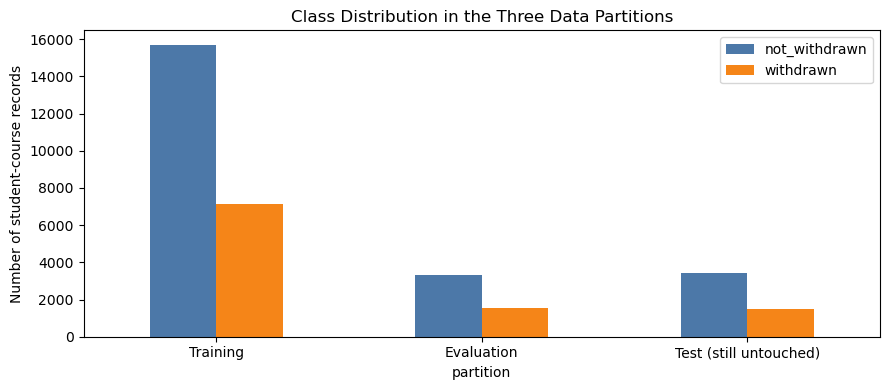

In [17]:
# Confirm that this section reuses the three-way group-safe split.
required_objects = [
    "X_train", "X_eval", "X_test", "y_train", "y_eval", "y_test",
    "numeric_features", "categorical_features", "preprocess"
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the earlier modeling cells before this section. Missing: "
        + ", ".join(missing_objects)
    )

augmentation_distribution_before = pd.DataFrame([
    {
        "partition": name,
        "not_withdrawn": int((target == 0).sum()),
        "withdrawn": int((target == 1).sum()),
        "withdrawal_percent": float((target == 1).mean() * 100),
        "rows": len(target),
    }
    for name, target in [
        ("Training", y_train),
        ("Evaluation", y_eval),
        ("Test (still untouched)", y_test),
    ]
])

display(augmentation_distribution_before.style.format({"withdrawal_percent": "{:.2f}%"}))
print("Training rows used for fitting/resampling:", len(X_train))
print("Evaluation rows used for strategy selection:", len(X_eval))
print("Test rows reserved for one final report:", len(X_test))

augmentation_distribution_before.set_index("partition")[[
    "not_withdrawn", "withdrawn"
]].plot(kind="bar", figsize=(9, 4), color=["#4C78A8", "#F58518"])
plt.title("Class Distribution in the Three Data Partitions")
plt.ylabel("Number of student-course records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 14.3.1 What “better than random” means during selection

The evaluation partition is used to compare candidate methods. Its majority-class accuracy
is the relevant simple accuracy baseline, while random ranking has ROC-AUC `0.50` and PR-AUC
equal to evaluation-set withdrawal prevalence.

Accuracy is not used alone: an always-not-withdrawn classifier can obtain a reasonable
accuracy while identifying no withdrawn students. Candidate decisions therefore emphasize
PR-AUC, withdrawal recall, F1, and the false-negative/false-positive trade-off.

In [18]:
# Calculate selection baselines from the evaluation partition, not the final test result.
withdrawal_prevalence = float((y_eval == 1).mean())
majority_accuracy_baseline = float(max((y_eval == 0).mean(), withdrawal_prevalence))
relative_balanced_withdrawal_weight = float((y_train == 0).sum() / (y_train == 1).sum())

baseline_reference_df = pd.DataFrame({
    "reference": [
        "50-50 coin-flip accuracy",
        "Always predict the evaluation majority class",
        "Random ROC-AUC",
        "Random PR-AUC on evaluation",
        "Balanced relative withdrawal weight from training",
    ],
    "value": [
        0.50,
        majority_accuracy_baseline,
        0.50,
        withdrawal_prevalence,
        relative_balanced_withdrawal_weight,
    ],
})

display(baseline_reference_df.style.format({"value": "{:.3f}"}))
print(
    f"Evaluation withdrawal prevalence={withdrawal_prevalence:.3f}; "
    f"evaluation majority accuracy={majority_accuracy_baseline:.3f}; "
    f"training-derived balanced relative weight={relative_balanced_withdrawal_weight:.3f}."
)

,reference,value
0,50-50 coin-flip accuracy,0.500
1,Always predict the evaluation majority class,0.683
2,Random ROC-AUC,0.500
3,Random PR-AUC on evaluation,0.317
4,Balanced relative withdrawal weight from training,2.197


Evaluation withdrawal prevalence=0.317; evaluation majority accuracy=0.683; training-derived balanced relative weight=2.197.


The three partitions should have similar withdrawal prevalence because the folds are
group-stratified. Exact row percentages can vary slightly because complete student groups
must stay together. The evaluation data is not passed to either resampling method, and the
test data is not used for strategy selection.

### 14.4 Leakage-safe preparation for SMOTENC

SMOTENC cannot work with missing values, so its imputers are fitted on the training
partition only. The fitted imputers transform the evaluation partition solely for
evaluation; the test partition remains unopened at this stage.

Encoding occurs after resampling so SMOTENC works with real categorical labels rather
than fractional one-hot indicators.

In [19]:
# Work on copies so the original partitions remain unchanged.
X_train_for_sampling = X_train.copy()
X_eval_for_selection = X_eval.copy()

augmentation_numeric_imputer = SimpleImputer(strategy="median")
augmentation_categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_for_sampling[numeric_features] = augmentation_numeric_imputer.fit_transform(
    X_train_for_sampling[numeric_features]
)
X_eval_for_selection[numeric_features] = augmentation_numeric_imputer.transform(
    X_eval_for_selection[numeric_features]
)

X_train_for_sampling[categorical_features] = augmentation_categorical_imputer.fit_transform(
    X_train_for_sampling[categorical_features]
)
X_eval_for_selection[categorical_features] = augmentation_categorical_imputer.transform(
    X_eval_for_selection[categorical_features]
)

for column in categorical_features:
    train_categories = pd.Index(X_train_for_sampling[column].unique())
    X_train_for_sampling[column] = pd.Categorical(
        X_train_for_sampling[column], categories=train_categories
    )
    X_eval_for_selection[column] = pd.Categorical(
        X_eval_for_selection[column], categories=train_categories
    )

assert not X_train_for_sampling.isna().any().any()
print("Training data prepared for mixed-type resampling:", X_train_for_sampling.shape)
print("Evaluation data transformed using training-fitted imputers:", X_eval_for_selection.shape)
print("Test data has not been transformed or evaluated in this section.")

Training data prepared for mixed-type resampling: (22833, 54)
Evaluation data transformed using training-fitted imputers: (4864, 54)
Test data has not been transformed or evaluated in this section.


### 14.5 Create the augmented training sets

Both methods balance the training classes to the majority-class count:

- Random Oversampling reaches this count by duplicating real withdrawal records.
- SMOTENC reaches it by generating additional mixed-type withdrawal records.

These augmented records are training aids. They are not added to the real dataset and
should not be interpreted as newly observed students.


,strategy,not_withdrawn,withdrawn,total
0,Original training data,15692,7141,22833
1,Random Oversampling,15692,15692,31384
2,SMOTENC,15692,15692,31384


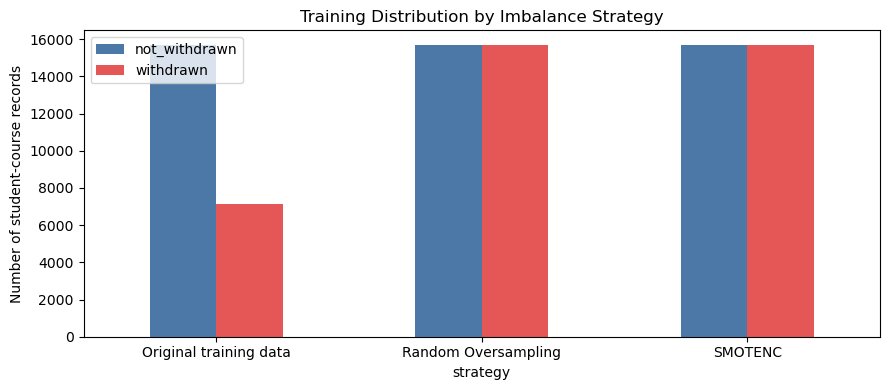

SMOTENC categorical validity check passed.


,invalid_categories
code_module,[]
code_presentation,[]
gender,[]
region,[]
highest_education,[]
imd_band,[]
age_band,[]
disability,[]


In [20]:
random_oversampler = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = random_oversampler.fit_resample(
    X_train_for_sampling, y_train
)

smotenc = SMOTENC(
    categorical_features=categorical_features,
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5,
)
X_train_smotenc, y_train_smotenc = smotenc.fit_resample(
    X_train_for_sampling, y_train
)

augmentation_distribution_after = pd.DataFrame([
    {
        "strategy": "Original training data",
        "not_withdrawn": int((y_train == 0).sum()),
        "withdrawn": int((y_train == 1).sum()),
        "total": len(y_train),
    },
    {
        "strategy": "Random Oversampling",
        "not_withdrawn": int((y_train_ros == 0).sum()),
        "withdrawn": int((y_train_ros == 1).sum()),
        "total": len(y_train_ros),
    },
    {
        "strategy": "SMOTENC",
        "not_withdrawn": int((y_train_smotenc == 0).sum()),
        "withdrawn": int((y_train_smotenc == 1).sum()),
        "total": len(y_train_smotenc),
    },
])
display(augmentation_distribution_after)

augmentation_distribution_after.set_index("strategy")[[
    "not_withdrawn", "withdrawn"
]].plot(kind="bar", figsize=(9, 4), color=["#4C78A8", "#E45756"])
plt.title("Training Distribution by Imbalance Strategy")
plt.ylabel("Number of student-course records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Confirm that SMOTENC did not invent new categorical labels.
smotenc_invalid_categories = {}
for column in categorical_features:
    original_values = set(X_train_for_sampling[column].dropna().astype(str))
    synthetic_values = set(X_train_smotenc[column].dropna().astype(str))
    invalid_values = sorted(synthetic_values - original_values)
    smotenc_invalid_categories[column] = invalid_values

assert all(len(values) == 0 for values in smotenc_invalid_categories.values())
print("SMOTENC categorical validity check passed.")
display(pd.Series(smotenc_invalid_categories, name="invalid_categories").to_frame())


### 14.6 Train the same HistGradientBoosting model three ways

Histogram Gradient Boosting groups numerical values into bins and builds small decision
trees sequentially. Each new tree focuses on errors left by the existing trees. This makes
it suitable for nonlinear patterns and interactions in tabular student data.

The model uses binary `log_loss`, meaning that it learns withdrawal probabilities and
penalizes confident incorrect probabilities strongly.

The configuration below is identical across strategies:

```python
HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=0.08,
    max_iter=200,
    random_state=42,
)
```

Only the weighted baseline receives sample weights. Oversampled variants are not also
weighted because doing both could over-correct the class imbalance.


In [21]:
def make_hgb_pipeline():
    return Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", HistGradientBoostingClassifier(
            loss="log_loss",
            learning_rate=0.08,
            max_iter=200,
            random_state=42,
        )),
    ])


def evaluate_hgb_strategy(strategy, model, y_training_used):
    probability = model.predict_proba(X_eval_for_selection)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_eval, prediction, labels=[0, 1]).ravel()

    return {
        "strategy": strategy,
        "training_rows": len(y_training_used),
        "training_withdrawn": int((y_training_used == 1).sum()),
        "accuracy": accuracy_score(y_eval, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_eval, prediction),
        "precision": precision_score(y_eval, prediction, zero_division=0),
        "recall": recall_score(y_eval, prediction, zero_division=0),
        "f1": f1_score(y_eval, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, probability),
        "pr_auc": average_precision_score(y_eval, probability),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }, probability, prediction


augmentation_models = {}
augmentation_predictions = {}
augmentation_result_rows = []

weighted_model = make_hgb_pipeline()
balanced_weights = compute_sample_weight(class_weight="balanced", y=y_train)
weighted_model.fit(
    X_train_for_sampling,
    y_train,
    model__sample_weight=balanced_weights,
)

ros_model = make_hgb_pipeline()
ros_model.fit(X_train_ros, y_train_ros)

smotenc_model = make_hgb_pipeline()
smotenc_model.fit(X_train_smotenc, y_train_smotenc)

fitted_strategies = [
    ("Balanced sample weights", weighted_model, y_train),
    ("Random Oversampling", ros_model, y_train_ros),
    ("SMOTENC", smotenc_model, y_train_smotenc),
]

for strategy, model, training_target in fitted_strategies:
    row, probability, prediction = evaluate_hgb_strategy(
        strategy, model, training_target
    )
    augmentation_models[strategy] = model
    augmentation_predictions[strategy] = {
        "probability": probability,
        "prediction": prediction,
    }
    augmentation_result_rows.append(row)

augmentation_results_df = pd.DataFrame(augmentation_result_rows).sort_values(
    ["f1", "pr_auc"], ascending=False
).reset_index(drop=True)

display(augmentation_results_df.style.format({
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
}))

,strategy,training_rows,training_withdrawn,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Balanced sample weights,22833,7141,0.832,0.813,0.724,0.759,0.741,0.883,0.824,2879,445,371,1169
1,Random Oversampling,31384,15692,0.832,0.808,0.731,0.744,0.737,0.880,0.819,2903,421,395,1145
2,SMOTENC,31384,15692,0.840,0.798,0.784,0.683,0.730,0.880,0.819,3034,290,488,1052


### 14.7 How to read the evaluation metrics

| Metric | Meaning in this project |
|---|---|
| Accuracy | Percentage of all students classified correctly; compare it with the `68.8%` majority-class baseline |
| Balanced accuracy | Average of withdrawal recall and non-withdrawal recall; gives both classes equal importance |
| Precision | Of the students flagged as likely to withdraw, how many actually withdrew |
| Recall | Of all students who actually withdrew, how many the model identified |
| F1 | A combined measure balancing withdrawal precision and recall |
| ROC-AUC | How well the model ranks withdrawn students above non-withdrawn students across thresholds; random ranking is `0.50` |
| PR-AUC | How well precision and recall are maintained for the withdrawal class; random ranking is approximately the positive-class prevalence (`0.312`) |
| False positive | A non-withdrawing student who is unnecessarily flagged |
| False negative | A withdrawing student whom the model misses |

Accuracy alone is not sufficient here. Always predicting **not withdrawn** would be correct
for most records but would have withdrawal recall `0`. Recall and false negatives are especially
important because the system is intended to identify students for early support. Precision still
matters because interventions require staff capacity. A useful strategy should therefore improve
withdrawal detection without producing an impractical number of false alerts.


In [22]:
baseline_row = (
    augmentation_results_df
    .set_index("strategy")
    .loc["Balanced sample weights"]
)

delta_columns = [
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
    "fp", "fn", "tp"
]
augmented_rows = augmentation_results_df[
    augmentation_results_df["strategy"] != "Balanced sample weights"
].set_index("strategy")

augmentation_delta_df = augmented_rows[delta_columns].subtract(
    baseline_row[delta_columns], axis="columns"
).reset_index()

display(
    augmentation_delta_df.style.format({
        "accuracy": "{:+.3f}",
        "precision": "{:+.3f}",
        "recall": "{:+.3f}",
        "f1": "{:+.3f}",
        "roc_auc": "{:+.3f}",
        "pr_auc": "{:+.3f}",
        "fp": "{:+.0f}",
        "fn": "{:+.0f}",
        "tp": "{:+.0f}",
    })
)

print("How to interpret the delta table:")
print("  Positive recall/F1/PR-AUC values indicate improvement over weighting.")
print("  Negative FN means fewer withdrawn students were missed.")
print("  Positive FP means more non-withdrawn students were flagged.")


,strategy,accuracy,precision,recall,f1,roc_auc,pr_auc,fp,fn,tp
0,Random Oversampling,+0.000,+0.007,-0.016,-0.004,-0.003,-0.006,-24,+24,-24
1,SMOTENC,+0.008,+0.060,-0.076,-0.011,-0.004,-0.006,-155,+117,-117


How to interpret the delta table:
  Positive recall/F1/PR-AUC values indicate improvement over weighting.
  Negative FN means fewer withdrawn students were missed.
  Positive FP means more non-withdrawn students were flagged.


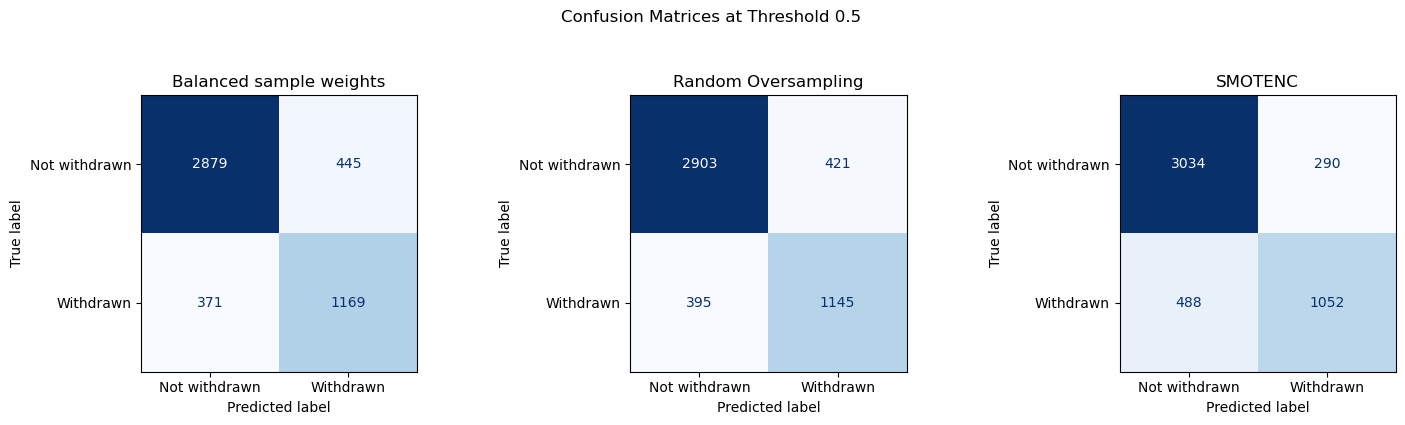

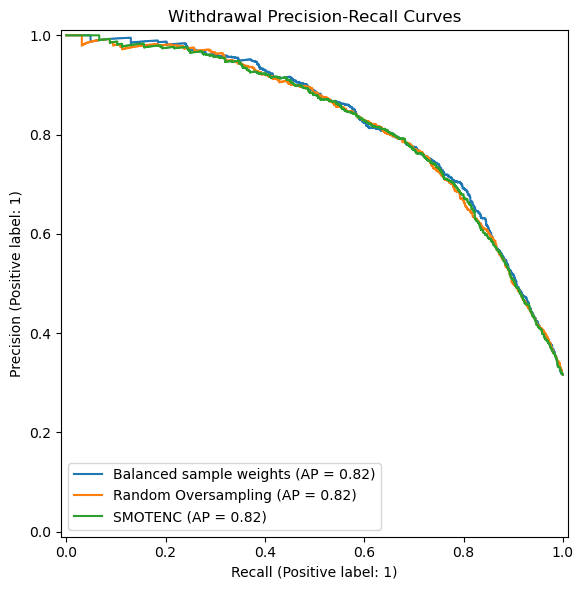

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, strategy in zip(axes, augmentation_models):
    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        augmentation_predictions[strategy]["prediction"],
        labels=[0, 1],
        display_labels=["Not withdrawn", "Withdrawn"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(strategy)
plt.suptitle("Confusion Matrices at Threshold 0.5", y=1.05)
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(8, 6))
for strategy in augmentation_models:
    PrecisionRecallDisplay.from_predictions(
        y_eval,
        augmentation_predictions[strategy]["probability"],
        name=strategy,
        ax=axis,
    )
axis.set_title("Withdrawal Precision-Recall Curves")
plt.tight_layout()
plt.show()


The confusion matrices show the operational effect at threshold `0.5`. Moving from the
weighted baseline to an augmented model is useful when the reduction in false negatives
is worth the corresponding increase in false positives. The precision-recall curves show
that this trade-off also changes when a different intervention threshold is selected.

The current section does not choose a new threshold because the institution's advisor
capacity and acceptable number of alerts have not yet been specified.


### 14.8 Subgroup performance check on evaluation data

Overall evaluation performance can hide weaker results for particular populations.
The following selection-time audit reports gender, disability, IMD band, highest education,
and credit-group metrics on the evaluation partition.

Groups with fewer than **50 evaluation records** or fewer than **10 actual withdrawals**
are excluded because very small percentages are unstable. This audit informs selection;
the final test result is still untouched.

In [24]:
subgroup_frame = X_eval.reset_index(drop=True).copy()
subgroup_frame["actual"] = y_eval.reset_index(drop=True)
subgroup_frame["credit_group"] = pd.cut(
    subgroup_frame["studied_credits"],
    bins=[-np.inf, 60, 90, 120, np.inf],
    labels=["Low (<=60)", "Medium (61-90)", "High (91-120)", "Very High (>120)"],
)

subgroup_attributes = [
    "gender", "disability", "imd_band", "highest_education", "credit_group"
]
subgroup_rows = []

for strategy, stored in augmentation_predictions.items():
    subgroup_frame["prediction"] = stored["prediction"]
    for attribute in subgroup_attributes:
        for group_value, group in subgroup_frame.groupby(attribute, observed=True):
            support = len(group)
            withdrawn = int(group["actual"].sum())
            if support < 50 or withdrawn < 10:
                continue

            tn, fp, fn, tp = confusion_matrix(
                group["actual"], group["prediction"], labels=[0, 1]
            ).ravel()
            subgroup_rows.append({
                "strategy": strategy,
                "attribute": attribute,
                "group": str(group_value),
                "support": support,
                "actual_withdrawn": withdrawn,
                "withdrawal_prevalence": withdrawn / support,
                "precision": precision_score(
                    group["actual"], group["prediction"], zero_division=0
                ),
                "recall": recall_score(
                    group["actual"], group["prediction"], zero_division=0
                ),
                "f1": f1_score(
                    group["actual"], group["prediction"], zero_division=0
                ),
                "false_negative_rate": fn / (tp + fn) if (tp + fn) else np.nan,
                "predicted_positive_rate": group["prediction"].mean(),
                "fp": int(fp),
                "fn": int(fn),
            })

subgroup_results_df = pd.DataFrame(subgroup_rows).sort_values(
    ["attribute", "strategy", "recall", "support"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

for attribute in subgroup_attributes:
    print()
    print(f"Subgroup results: {attribute}")
    display(
        subgroup_results_df[
            subgroup_results_df["attribute"] == attribute
        ].style.format({
            "withdrawal_prevalence": "{:.1%}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "false_negative_rate": "{:.3f}",
            "predicted_positive_rate": "{:.1%}",
        })
    )



Subgroup results: gender


,strategy,attribute,group,support,actual_withdrawn,withdrawal_prevalence,precision,recall,f1,false_negative_rate,predicted_positive_rate,fp,fn
18,Balanced sample weights,gender,M,2692,864,32.1%,0.725,0.749,0.736,0.251,33.2%,246,217
19,Balanced sample weights,gender,F,2172,676,31.1%,0.724,0.772,0.747,0.228,33.2%,199,154
20,Random Oversampling,gender,M,2692,864,32.1%,0.724,0.730,0.727,0.270,32.4%,241,233
21,Random Oversampling,gender,F,2172,676,31.1%,0.741,0.760,0.750,0.240,32.0%,180,162
22,SMOTENC,gender,M,2692,864,32.1%,0.777,0.674,0.722,0.326,27.8%,167,282
23,SMOTENC,gender,F,2172,676,31.1%,0.793,0.695,0.741,0.305,27.3%,123,206



Subgroup results: disability


,strategy,attribute,group,support,actual_withdrawn,withdrawal_prevalence,precision,recall,f1,false_negative_rate,predicted_positive_rate,fp,fn
12,Balanced sample weights,disability,N,4393,1356,30.9%,0.727,0.753,0.740,0.247,32.0%,384,335
13,Balanced sample weights,disability,Y,471,184,39.1%,0.708,0.804,0.753,0.196,44.4%,61,36
14,Random Oversampling,disability,N,4393,1356,30.9%,0.731,0.735,0.733,0.265,31.0%,366,360
15,Random Oversampling,disability,Y,471,184,39.1%,0.730,0.810,0.768,0.190,43.3%,55,35
16,SMOTENC,disability,N,4393,1356,30.9%,0.779,0.677,0.725,0.323,26.8%,260,438
17,SMOTENC,disability,Y,471,184,39.1%,0.817,0.728,0.770,0.272,34.8%,30,50



Subgroup results: imd_band


,strategy,attribute,group,support,actual_withdrawn,withdrawal_prevalence,precision,recall,f1,false_negative_rate,predicted_positive_rate,fp,fn
36,Balanced sample weights,imd_band,Unknown,151,38,25.2%,0.808,0.553,0.656,0.447,17.2%,5,17
37,Balanced sample weights,imd_band,30-40%,571,184,32.2%,0.701,0.712,0.706,0.288,32.7%,56,53
38,Balanced sample weights,imd_band,60-70%,440,135,30.7%,0.770,0.719,0.743,0.281,28.6%,29,38
39,Balanced sample weights,imd_band,80-90%,412,101,24.5%,0.692,0.733,0.712,0.267,26.0%,33,27
40,Balanced sample weights,imd_band,50-60%,484,146,30.2%,0.695,0.733,0.713,0.267,31.8%,47,39
41,Balanced sample weights,imd_band,90-100%,376,94,25.0%,0.755,0.755,0.755,0.245,25.0%,23,23
42,Balanced sample weights,imd_band,40-50%,511,163,31.9%,0.710,0.767,0.737,0.233,34.4%,51,38
43,Balanced sample weights,imd_band,70-80%,410,122,29.8%,0.803,0.770,0.787,0.230,28.5%,23,28
44,Balanced sample weights,imd_band,20-30%,564,213,37.8%,0.751,0.793,0.772,0.207,39.9%,56,44
45,Balanced sample weights,imd_band,0-10%,476,172,36.1%,0.690,0.814,0.747,0.186,42.6%,63,32



Subgroup results: highest_education


,strategy,attribute,group,support,actual_withdrawn,withdrawal_prevalence,precision,recall,f1,false_negative_rate,predicted_positive_rate,fp,fn
24,Balanced sample weights,highest_education,HE Qualification,723,202,27.9%,0.746,0.713,0.729,0.287,26.7%,49,58
25,Balanced sample weights,highest_education,A Level or Equivalent,2077,626,30.1%,0.737,0.738,0.737,0.262,30.2%,165,164
26,Balanced sample weights,highest_education,Lower Than A Level,1961,681,34.7%,0.708,0.790,0.747,0.210,38.8%,222,143
27,Balanced sample weights,highest_education,No Formal quals,55,23,41.8%,0.750,0.913,0.824,0.087,50.9%,7,2
28,Random Oversampling,highest_education,HE Qualification,723,202,27.9%,0.743,0.688,0.715,0.312,25.9%,48,63
29,Random Oversampling,highest_education,A Level or Equivalent,2077,626,30.1%,0.743,0.725,0.734,0.275,29.4%,157,172
30,Random Oversampling,highest_education,Lower Than A Level,1961,681,34.7%,0.717,0.772,0.743,0.228,37.4%,208,155
31,Random Oversampling,highest_education,No Formal quals,55,23,41.8%,0.759,0.957,0.846,0.043,52.7%,7,1
32,SMOTENC,highest_education,HE Qualification,723,202,27.9%,0.810,0.634,0.711,0.366,21.9%,30,74
33,SMOTENC,highest_education,A Level or Equivalent,2077,626,30.1%,0.805,0.660,0.725,0.340,24.7%,100,213



Subgroup results: credit_group


,strategy,attribute,group,support,actual_withdrawn,withdrawal_prevalence,precision,recall,f1,false_negative_rate,predicted_positive_rate,fp,fn
0,Balanced sample weights,credit_group,Low (<=60),3031,762,25.1%,0.679,0.701,0.689,0.299,26.0%,253,228
1,Balanced sample weights,credit_group,Medium (61-90),529,198,37.4%,0.745,0.753,0.749,0.247,37.8%,51,49
2,Balanced sample weights,credit_group,High (91-120),992,404,40.7%,0.761,0.837,0.797,0.163,44.8%,106,66
3,Balanced sample weights,credit_group,Very High (>120),312,176,56.4%,0.809,0.841,0.825,0.159,58.7%,35,28
4,Random Oversampling,credit_group,Low (<=60),3031,762,25.1%,0.678,0.688,0.683,0.312,25.5%,249,238
5,Random Oversampling,credit_group,Medium (61-90),529,198,37.4%,0.762,0.742,0.752,0.258,36.5%,46,51
6,Random Oversampling,credit_group,High (91-120),992,404,40.7%,0.778,0.817,0.797,0.183,42.7%,94,74
7,Random Oversampling,credit_group,Very High (>120),312,176,56.4%,0.818,0.818,0.818,0.182,56.4%,32,32
8,SMOTENC,credit_group,Low (<=60),3031,762,25.1%,0.736,0.622,0.674,0.378,21.2%,170,288
9,SMOTENC,credit_group,Medium (61-90),529,198,37.4%,0.806,0.672,0.733,0.328,31.2%,32,65


In [25]:
# Compact summary of the range of subgroup recall for each strategy and attribute.
subgroup_recall_summary = (
    subgroup_results_df
    .groupby(["strategy", "attribute"])
    .agg(
        groups_reported=("group", "count"),
        minimum_recall=("recall", "min"),
        maximum_recall=("recall", "max"),
        recall_gap=("recall", lambda values: values.max() - values.min()),
    )
    .reset_index()
)

display(
    subgroup_recall_summary.style.format({
        "minimum_recall": "{:.3f}",
        "maximum_recall": "{:.3f}",
        "recall_gap": "{:.3f}",
    })
)

print(
    "A smaller recall gap suggests more consistent withdrawal detection across the "
    "reported groups, but it must be considered alongside overall precision, recall, "
    "sample sizes, and the observed withdrawal prevalence."
)


,strategy,attribute,groups_reported,minimum_recall,maximum_recall,recall_gap
0,Balanced sample weights,credit_group,4,0.701,0.841,0.140
1,Balanced sample weights,disability,2,0.753,0.804,0.051
2,Balanced sample weights,gender,2,0.749,0.772,0.023
3,Balanced sample weights,highest_education,4,0.713,0.913,0.200
4,Balanced sample weights,imd_band,11,0.553,0.814,0.261
5,Random Oversampling,credit_group,4,0.688,0.818,0.131
6,Random Oversampling,disability,2,0.735,0.810,0.075
7,Random Oversampling,gender,2,0.730,0.760,0.030
8,Random Oversampling,highest_education,4,0.688,0.957,0.268
9,Random Oversampling,imd_band,11,0.526,0.802,0.276


A smaller recall gap suggests more consistent withdrawal detection across the reported groups, but it must be considered alongside overall precision, recall, sample sizes, and the observed withdrawal prevalence.


### 14.9 Evidence-based decision rule using evaluation data

No strategy is selected merely because it balances the training table. Evaluation results
must show a useful trade-off. The preferred strategy should:

1. reduce false negatives or improve withdrawal recall;
2. retain useful precision;
3. maintain or improve F1 and PR-AUC;
4. avoid materially worse evaluation results for represented groups; and
5. use the simplest method when results are similar.

The test partition is not part of this decision.

In [26]:
baseline = augmentation_results_df.set_index("strategy").loc["Balanced sample weights"]
augmented_only = augmentation_results_df[
    augmentation_results_df["strategy"] != "Balanced sample weights"
]
best_f1_augmented = augmented_only.sort_values(
    ["f1", "pr_auc"], ascending=False
).iloc[0]
best_recall = augmentation_results_df.sort_values(
    ["recall", "precision"], ascending=False
).iloc[0]

print("FINAL AUGMENTATION INTERPRETATION")
print("=" * 35)
print(
    f"Weighted baseline: recall={baseline['recall']:.3f}, "
    f"precision={baseline['precision']:.3f}, F1={baseline['f1']:.3f}, "
    f"PR-AUC={baseline['pr_auc']:.3f}, FP={int(baseline['fp'])}, "
    f"FN={int(baseline['fn'])}."
)
print(
    f"Best augmented F1: {best_f1_augmented['strategy']} with "
    f"recall={best_f1_augmented['recall']:.3f}, "
    f"precision={best_f1_augmented['precision']:.3f}, "
    f"F1={best_f1_augmented['f1']:.3f}, "
    f"PR-AUC={best_f1_augmented['pr_auc']:.3f}."
)
print(
    f"Compared with weighting, it identifies "
    f"{int(best_f1_augmented['tp'] - baseline['tp']):+d} additional actual withdrawals, "
    f"misses {int(best_f1_augmented['fn'] - baseline['fn']):+d} withdrawals, and creates "
    f"{int(best_f1_augmented['fp'] - baseline['fp']):+d} additional false-positive alerts."
)
print(
    f"Highest recall overall: {best_recall['strategy']} "
    f"({best_recall['recall']:.3f})."
)

if (
    best_f1_augmented["f1"] > baseline["f1"]
    and best_f1_augmented["recall"] >= baseline["recall"]
):
    recommendation = (
        f"Carry {best_f1_augmented['strategy']} forward as the leading augmentation "
        "candidate, subject to the subgroup results and intervention capacity."
    )
else:
    recommendation = (
        "Keep balanced sample weighting as the preferred strategy because the tested "
        "augmentation methods do not improve both withdrawal recall and F1."
    )

print("Recommendation:", recommendation)


FINAL AUGMENTATION INTERPRETATION
Weighted baseline: recall=0.759, precision=0.724, F1=0.741, PR-AUC=0.824, FP=445, FN=371.
Best augmented F1: Random Oversampling with recall=0.744, precision=0.731, F1=0.737, PR-AUC=0.819.
Compared with weighting, it identifies -24 additional actual withdrawals, misses +24 withdrawals, and creates -24 additional false-positive alerts.
Highest recall overall: Balanced sample weights (0.759).
Recommendation: Keep balanced sample weighting as the preferred strategy because the tested augmentation methods do not improve both withdrawal recall and F1.


### 14.9.1 Recorded augmentation outcome on evaluation data

| Strategy | Precision | Recall | F1 | ROC-AUC | PR-AUC | False positives | False negatives |
|---|---:|---:|---:|---:|---:|---:|---:|
| Balanced sample weights | 0.724 | **0.759** | **0.741** | **0.883** | **0.824** | 445 | **371** |
| Random Oversampling | 0.731 | 0.744 | 0.737 | 0.880 | 0.819 | 421 | 395 |
| SMOTENC | **0.784** | 0.683 | 0.730 | 0.880 | 0.819 | **290** | 488 |

Random Oversampling reduced false positives by 24 but created 24 additional false negatives.
SMOTENC reduced false positives by 155 but created 117 additional false negatives. Neither
improved both withdrawal recall and F1, so sample weighting remains the preferred imbalance
**method**. This conclusion was made without viewing final test performance.


### 14.9.2 Evaluation sensitivity to withdrawal weight

Balanced weighting keeps the original training rows and changes the relative cost of
withdrawal errors. The experiment tests relative withdrawal weights of `1.0`, `1.5`,
`2.0`, the training-derived balanced ratio, `3.0`, and `4.0`.

Every candidate is fitted on training data and compared only on evaluation data. Weight
vectors are normalized to mean `1` so that the experiment changes relative class emphasis
rather than total supplied weight.

In [27]:
# Test whether the result is sensitive to the chosen withdrawal-class weight.
balanced_relative_ratio = float((y_train == 0).sum() / (y_train == 1).sum())
weight_candidates = [1.0, 1.5, 2.0, balanced_relative_ratio, 3.0, 4.0]
weight_sensitivity_rows = []
weight_sensitivity_models = {}

for relative_weight in weight_candidates:
    candidate_weights = np.where(y_train.to_numpy() == 1, relative_weight, 1.0).astype(float)
    candidate_weights /= candidate_weights.mean()

    candidate_model = make_hgb_pipeline()
    candidate_model.fit(
        X_train_for_sampling,
        y_train,
        model__sample_weight=candidate_weights,
    )
    row, probability, prediction = evaluate_hgb_strategy(
        f"Withdrawal weight {relative_weight:.3f}",
        candidate_model,
        y_train,
    )
    row["relative_withdrawal_weight"] = relative_weight
    weight_sensitivity_rows.append(row)
    weight_sensitivity_models[relative_weight] = candidate_model

weight_sensitivity_df = pd.DataFrame(weight_sensitivity_rows).sort_values(
    "relative_withdrawal_weight"
).reset_index(drop=True)

display(
    weight_sensitivity_df[[
        "relative_withdrawal_weight", "accuracy", "balanced_accuracy",
        "precision", "recall", "f1", "roc_auc", "pr_auc", "fp", "fn"
    ]].style.format({
        "relative_withdrawal_weight": "{:.3f}",
        "accuracy": "{:.3f}",
        "balanced_accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "roc_auc": "{:.3f}",
        "pr_auc": "{:.3f}",
    })
)

best_weight_f1 = weight_sensitivity_df.sort_values(
    ["f1", "recall"], ascending=False
).iloc[0]
best_weight_recall = weight_sensitivity_df.sort_values(
    ["recall", "precision"], ascending=False
).iloc[0]

print(
    f"Best F1 weight={best_weight_f1['relative_withdrawal_weight']:.3f}: "
    f"precision={best_weight_f1['precision']:.3f}, recall={best_weight_f1['recall']:.3f}, "
    f"F1={best_weight_f1['f1']:.3f}, FN={int(best_weight_f1['fn'])}, "
    f"FP={int(best_weight_f1['fp'])}."
)
print(
    f"Highest recall weight={best_weight_recall['relative_withdrawal_weight']:.3f}: "
    f"recall={best_weight_recall['recall']:.3f}, precision={best_weight_recall['precision']:.3f}, "
    f"FN={int(best_weight_recall['fn'])}, FP={int(best_weight_recall['fp'])}."
)


,relative_withdrawal_weight,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,fp,fn
0,1.000,0.839,0.790,0.797,0.658,0.721,0.883,0.823,259,526
1,1.500,0.838,0.804,0.762,0.710,0.735,0.883,0.824,342,446
2,2.000,0.835,0.812,0.736,0.748,0.742,0.884,0.824,414,388
3,2.197,0.832,0.813,0.724,0.759,0.741,0.883,0.824,445,371
4,3.000,0.825,0.819,0.693,0.803,0.744,0.884,0.825,548,303
5,4.000,0.793,0.803,0.632,0.831,0.718,0.883,0.823,745,261


Best F1 weight=3.000: precision=0.693, recall=0.803, F1=0.744, FN=303, FP=548.
Highest recall weight=4.000: recall=0.831, precision=0.632, FN=261, FP=745.


#### Recorded evaluation weight-sensitivity outcome

| Relative withdrawal weight | Accuracy | Balanced accuracy | Precision | Recall | F1 | PR-AUC | FP | FN |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1.000 | **0.839** | 0.790 | **0.797** | 0.658 | 0.721 | 0.823 | **259** | 526 |
| 1.500 | 0.838 | 0.804 | 0.762 | 0.710 | 0.735 | 0.824 | 342 | 446 |
| 2.000 | 0.835 | 0.812 | 0.736 | 0.748 | 0.742 | 0.824 | 414 | 388 |
| 2.197 (automatic balance) | 0.832 | 0.813 | 0.724 | 0.759 | 0.741 | 0.824 | 445 | 371 |
| 3.000 | 0.825 | **0.819** | 0.693 | 0.803 | **0.744** | **0.825** | 548 | 303 |
| 4.000 | 0.793 | 0.803 | 0.632 | **0.831** | 0.718 | 0.823 | 745 | **261** |

Increasing the withdrawal weight raises recall and reduces false negatives, but lowers precision
and increases false alerts. Weight `3.0` gives the strongest evaluation F1 and PR-AUC while
raising recall to `0.803`. Weight `4.0` raises recall further but its F1 falls sharply, so it is
not selected.

The automatically balanced ratio is a reproducible default. Weight `3.0` is selected here only
because the stated project priority gives greater importance to missed withdrawals and the
evaluation result maintained F1 and PR-AUC.


### 14.9.3 Freeze the final candidate before opening the test set

The baseline comparison selected weighted XGBoost among the original four models. The weight
sensitivity experiment produced one additional candidate: HistGradientBoosting with relative
withdrawal weight `3.0`.

The two are treated as practically tied when their evaluation PR-AUC and F1 differ by less than
`0.005`. Within such a tie, the candidate with higher withdrawal recall is preferred because
false negatives represent missed support opportunities. The selected candidate is fixed here;
the final test result cannot change this decision.


In [28]:
xgb_evaluation = results_df.set_index("model").loc["XGBoost_weighted"]
hgb_weight_three = (
    weight_sensitivity_df
    .iloc[(weight_sensitivity_df["relative_withdrawal_weight"] - 3.0).abs().argsort()[:1]]
    .iloc[0]
)

final_candidate_comparison = pd.DataFrame([
    {
        "candidate": "XGBoost with balanced sample weights",
        "pr_auc": xgb_evaluation["pr_auc"],
        "f1": xgb_evaluation["f1_at_0_5"],
        "precision": xgb_evaluation["precision_at_0_5"],
        "recall": xgb_evaluation["recall_at_0_5"],
        "fp": int(xgb_evaluation["fp"]),
        "fn": int(xgb_evaluation["fn"]),
    },
    {
        "candidate": "HistGradientBoosting with withdrawal weight 3.0",
        "pr_auc": hgb_weight_three["pr_auc"],
        "f1": hgb_weight_three["f1"],
        "precision": hgb_weight_three["precision"],
        "recall": hgb_weight_three["recall"],
        "fp": int(hgb_weight_three["fp"]),
        "fn": int(hgb_weight_three["fn"]),
    },
])
display(final_candidate_comparison.style.format({
    "pr_auc": "{:.4f}",
    "f1": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
}))

pr_auc_tied = abs(xgb_evaluation["pr_auc"] - hgb_weight_three["pr_auc"]) < 0.005
f1_tied = abs(xgb_evaluation["f1_at_0_5"] - hgb_weight_three["f1"]) < 0.005

if pr_auc_tied and f1_tied and hgb_weight_three["recall"] > xgb_evaluation["recall_at_0_5"]:
    selected_final_candidate = "HistGradientBoosting_weight_3.000"
    selected_relative_weight = 3.0
    selection_reason = (
        "PR-AUC and F1 are practically tied, while the HGB weight-3 candidate has "
        "higher withdrawal recall and fewer false negatives on evaluation data."
    )
else:
    selected_final_candidate = "XGBoost_weighted"
    selected_relative_weight = None
    selection_reason = (
        "The XGBoost candidate provides the stronger evaluation trade-off under the "
        "predefined tolerance rule."
    )

print("Frozen final candidate:", selected_final_candidate)
print("Reason:", selection_reason)
print("The test set has not influenced this selection.")


,candidate,pr_auc,f1,precision,recall,fp,fn
0,XGBoost with balanced sample weights,0.8244,0.7435,0.7239,0.7643,449,363
1,HistGradientBoosting with withdrawal weight 3.0,0.8248,0.7441,0.6930,0.8032,548,303


Frozen final candidate: HistGradientBoosting_weight_3.000
Reason: PR-AUC and F1 are practically tied, while the HGB weight-3 candidate has higher withdrawal recall and fewer false negatives on evaluation data.
The test set has not influenced this selection.


## 15. Final Untouched-Test Evaluation

Only after model-family and imbalance comparisons are complete is the selected candidate
refitted on the combined training and evaluation partitions. Preprocessing is refitted on
that development data only. The test partition is transformed and scored once for the final
unbiased report.

In [29]:
# Refit the frozen candidate on combined training + evaluation data.
X_development = pd.concat([X_train, X_eval], axis=0)
y_development = pd.concat([y_train, y_eval], axis=0)

if selected_final_candidate == "HistGradientBoosting_weight_3.000":
    final_estimator = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.08,
        max_iter=200,
        random_state=42,
    )
    final_model = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", final_estimator),
    ])
    development_weights = np.where(
        y_development.to_numpy() == 1,
        selected_relative_weight,
        1.0,
    ).astype(float)
    development_weights /= development_weights.mean()
    final_fit_kwargs = {"model__sample_weight": development_weights}
else:
    final_model = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", clone(candidate_models["XGBoost_weighted"])),
    ])
    development_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_development,
    )
    final_fit_kwargs = {"model__sample_weight": development_weights}

final_model.fit(X_development, y_development, **final_fit_kwargs)
final_test_probability = final_model.predict_proba(X_test)[:, 1]
final_test_row = metric_row(
    selected_final_candidate,
    y_test,
    final_test_probability,
    threshold=0.5,
)
final_test_results_df = pd.DataFrame([final_test_row])
display(final_test_results_df.style.format({
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
    "precision_at_0_5": "{:.3f}",
    "recall_at_0_5": "{:.3f}",
    "f1_at_0_5": "{:.3f}",
}))

final_test_prediction = (final_test_probability >= 0.5).astype(int)
print("Final selected model:", selected_final_candidate)
print("Final untouched-test confusion matrix:")
print(confusion_matrix(y_test, final_test_prediction, labels=[0, 1]))
print(classification_report(
    y_test,
    final_test_prediction,
    target_names=["not_withdrawn", "withdrawn"],
))


,model,accuracy,balanced_accuracy,roc_auc,pr_auc,precision_at_0_5,recall_at_0_5,f1_at_0_5,tn,fp,fn,tp
0,HistGradientBoosting_weight_3.000,0.816,0.804,0.874,0.797,0.667,0.775,0.717,2851,570,332,1143


Final selected model: HistGradientBoosting_weight_3.000
Final untouched-test confusion matrix:
[[2851  570]
 [ 332 1143]]
               precision    recall  f1-score   support

not_withdrawn       0.90      0.83      0.86      3421
    withdrawn       0.67      0.77      0.72      1475

     accuracy                           0.82      4896
    macro avg       0.78      0.80      0.79      4896
 weighted avg       0.83      0.82      0.82      4896



### 15.1 Recorded final test outcome

The frozen `HistGradientBoosting_weight_3.000` candidate achieved accuracy `0.816`, balanced
accuracy `0.804`, ROC-AUC `0.874`, PR-AUC `0.797`, withdrawal precision `0.667`, recall
`0.775`, and F1 `0.717`.

It correctly identified `1,143` of `1,475` withdrawn enrollments and missed `332`. It produced
`570` false-positive support alerts among the `3,421` non-withdrawn enrollments. These numbers
are the final report; evaluation metrics remain selection evidence and must not replace them.


## 16. How to explain the complete experiment

> I created training, evaluation, and test partitions in a 70/15/15 design and kept every
> student's enrollments in one partition. Preprocessing, weighting, and augmentation were fitted
> only on training data. Evaluation data compared Logistic Regression, Random Forest,
> HistGradientBoosting, and XGBoost. XGBoost was slightly better among the four original models,
> but a subsequent evaluation-only weight experiment showed that HistGradientBoosting with
> withdrawal weight 3.0 had practically the same PR-AUC and F1 while identifying more actual
> withdrawals. I froze that candidate, refitted it on training plus evaluation data, and scored
> the test set once. The final test recall was 0.775, PR-AUC 0.797, and ROC-AUC 0.874.

The main conclusions remain:

- early missing assessments and VLE disengagement are the strongest signals;
- standard log loss with sample weighting is sufficient;
- synthetic augmentation did not improve the required recall/F1 trade-off;
- XGBoost is competitive but did not provide the preferred recall after weight sensitivity;
- accuracy is reported against the majority baseline and is never used alone;
- the final test result, not the evaluation result, is the unbiased performance report.

**Remaining limitations**

- One fixed group-stratified split is used; repeated grouped or temporal validation is stronger.
- Assessment score-availability timing should be verified independently.
- Students already withdrawn before the checkpoint should be excluded operationally.
- Threshold `0.5` still requires capacity-based selection and calibration review.


## 17. Separate Note: What Changed Compared with the Original Notebook?

This section deliberately separates the comparison from the main experiment. The two notebooks
do not use the same split or model-selection procedure, so their metric values should **not** be
treated as a direct like-for-like contest.

| Area | Original notebook | New notebook | Did the conclusion change? |
|---|---|---|---|
| Main risk signals | Missing early assessments, unavailable scores, and low/recent VLE engagement were the strongest signals. | The same signals remain important. | **No.** The subject-matter interpretation is unchanged. |
| Data split | A 75/25 enrollment-row split was used. The same student could occur in both partitions, and the holdout was repeatedly consulted during model, augmentation, and weight comparisons. | A group-aware 70/15/15 train/evaluation/test split keeps every student's enrollments in one partition. Model decisions use evaluation data; test data is scored once. | **Yes—methodologically.** The new estimate is more defensible and has lower leakage risk. |
| Preprocessing | Some medians and missing-value substitutions were calculated before splitting. No VLE activity could also be represented as zero days since activity. | Imputation and encoding are learned from training data only. A separate no-early-VLE-activity flag distinguishes absence of activity from genuine recency. | **Yes.** Missingness is represented more accurately and safely. |
| Models compared | Logistic Regression, Random Forest, and HistGradientBoosting were compared; weighted HistGradientBoosting was selected. | XGBoost is added. It narrowly leads the initial four-model evaluation, but HistGradientBoosting with withdrawal weight `3.0` is selected after the predefined practical-tie and recall rule. | **Partly.** HGB remains the final model family, but XGBoost is now a credible close alternative and the selected weight changes. |
| Class imbalance | Automatic balanced weighting (approximately `2.209` for withdrawals) was retained. | Evaluation-only sensitivity testing selects withdrawal weight `3.0`, accepting more false alerts to miss fewer withdrawn students. | **Yes.** The operating trade-off moves toward recall. |
| Random oversampling and SMOTENC | Neither improved the required overall trade-off over sample weighting. | The same conclusion is obtained on the new evaluation partition. | **No.** Sample weighting remains the preferred approach. |
| PCA | PCA was not recommended for the tree models; 39 components explained 95% of encoded variance in an exploratory full-data fit. | PCA is fitted only on training data; 39 components again explain 95% of its encoded variance. It is still not used for the tree models. | **No substantive change.** The leakage control is improved. |
| Fairness/subgroup audit | Recall gaps existed across several groups, especially education and IMD categories. | Exact gaps change on the new evaluation partition; education and IMD categories still require attention. | **No broad change.** The need for subgroup monitoring remains. |

### Metric comparison

| Metric at threshold 0.5 | Original weighted HGB holdout | New final untouched-test HGB |
|---|---:|---:|
| Accuracy | `0.831` | `0.816` |
| ROC-AUC | `0.882` | `0.874` |
| PR-AUC | `0.818` | `0.797` |
| Withdrawal precision | `0.717` | `0.667` |
| Withdrawal recall | `0.756` | `0.775` |
| Withdrawal F1 | `0.736` | `0.717` |

The new model catches a larger proportion of actual withdrawals (`0.775` versus `0.756` recall),
but it has lower precision, F1, ROC-AUC, and PR-AUC. This is the expected cost of choosing a
more recall-oriented weight: the model misses fewer at-risk enrollments but creates more support
alerts. The lower headline metrics do not mean that the new procedure is worse. They are measured
under a stricter student-grouped split with a test set that was not used to choose the model, so
they should be treated as a more credible estimate of performance on unseen students.

The confusion matrices are also not directly comparable because the partitions have different
sizes. The final new test result contains `1,143` true positives, `332` false negatives, `570`
false positives, and `2,851` true negatives.

### Important evidence note

The original notebook contains an older static narrative quoting ROC-AUC `0.881`, PR-AUC `0.820`,
precision `0.721`, recall `0.753`, and F1 `0.737`. Those values are close to, but not identical to,
the original notebook's currently executed weighted-HGB output shown above. They should not be
mixed with the new notebook's results. This notebook records conclusions next to the corresponding
executed outputs to keep selection evidence and final test evidence separate.

### Bottom line

- The **data finding** did not change: early assessment non-participation and VLE disengagement
  remain the clearest warning signals.
- The **augmentation finding** did not change: sample weighting is more useful here than creating
  duplicate or synthetic training rows.
- The **model-selection finding changed slightly**: XGBoost is highly competitive, while HGB is
  retained only after an explicit recall-focused weight comparison.
- The **reported performance changed**: recall improved, while precision and ranking metrics fell.
  The new result is preferred because its leakage controls and untouched test set make it more
  trustworthy, not because every metric is numerically higher.
- The result is still based on one grouped split. Repeated grouped validation or a genuinely
  time-based validation remains the appropriate next robustness check.


## 18. Final Summary

This section collects the final modeling inputs, selected model, and augmentation result in one
place. It is the concise summary to use when presenting the experiment.

### 18.1 Features used for modeling

The model uses **54 raw predictors: 46 numeric and 8 categorical**. One-hot encoding expands the
training matrix to 93 columns. PCA was investigated but is **not** used by the final tree model.

**Student profile and course context**

- Numeric: `num_of_prev_attempts`, `studied_credits`, `module_presentation_length`,
  `checkpoint_day`
- Categorical: `code_module`, `code_presentation`, `gender`, `region`, `highest_education`,
  `imd_band`, `age_band`, `disability`

**Registration timing**

- `date_registration`
- `registration_missing_flag`
- `registered_before_start_days`
- `registered_after_start_flag`

**Early VLE engagement, restricted to the 25% checkpoint**

- `total_clicks_25pct`
- `vle_events_25pct`
- `active_days_25pct`
- `distinct_sites_25pct`
- `last_activity_day_25pct`
- `days_since_last_activity_at_checkpoint`
- `no_early_vle_activity_flag`
- `clicks_dataplus_25pct`
- `clicks_forumng_25pct`
- `clicks_other_activity_25pct`
- `clicks_oucollaborate_25pct`
- `clicks_oucontent_25pct`
- `clicks_quiz_25pct`
- `clicks_resource_25pct`
- `clicks_subpage_25pct`
- `clicks_url_25pct`
- `clicks_externalquiz_25pct`
- `clicks_ouwiki_25pct`
- `clicks_page_25pct`
- `clicks_questionnaire_25pct`

**Early assessment behavior, restricted to the 25% checkpoint**

- `early_assessments_submitted_count`
- `early_assessments_due_count`
- `early_assessments_missing_count`
- `early_assessment_weight_total`
- `submitted_early_weight_total`
- `mean_early_score`
- `min_early_score`
- `max_early_score`
- `weighted_early_score`
- `early_score_missing_count`
- `average_submission_delay`
- `late_submission_count`
- `banked_assessment_count`
- `mean_early_score_missing_flag`
- `min_early_score_missing_flag`
- `max_early_score_missing_flag`
- `weighted_early_score_missing_flag`
- `average_submission_delay_missing_flag`

`id_student` is used only to keep students in a single data partition; it is not a predictor.
`target_dropout`, `final_result`, `date_unregistration`, and all post-checkpoint activity are
excluded to prevent target or future-information leakage.

### 18.2 Final selected model

The final model is **HistGradientBoostingClassifier with withdrawal weight 3.0**:

- loss function: standard binary `log_loss`
- learning rate: `0.08`
- boosting iterations (`max_iter`): `200`
- relative sample weight: non-withdrawal `1.0`, withdrawal `3.0`
- classification threshold: `0.5`
- random seed: `42`

XGBoost narrowly led the initial four-model comparison. However, XGBoost and the weight-3 HGB
candidate were within the predefined `0.005` practical-tie tolerance for PR-AUC and F1. HGB was
selected because its evaluation recall was higher (`0.803` versus `0.764`) and it produced 60
fewer false negatives, which matches the project's priority of identifying students needing
support. This benefit came with 99 additional false-positive alerts.

After the decision was frozen, the HGB pipeline was refitted on training plus evaluation data and
scored once on the untouched test partition:

| Test metric | Final result |
|---|---:|
| Accuracy | `0.816` |
| Balanced accuracy | `0.804` |
| ROC-AUC | `0.874` |
| PR-AUC | `0.797` |
| Withdrawal precision | `0.667` |
| Withdrawal recall | `0.775` |
| Withdrawal F1 | `0.717` |

The final test confusion matrix contains `2,851` true negatives, `570` false positives, `332`
false negatives, and `1,143` true positives.

### 18.3 Outcome of augmentation and imbalance handling

Three approaches were compared using training data only and evaluated on the same evaluation
partition:

| Imbalance strategy | Precision | Recall | F1 | ROC-AUC | PR-AUC | FP | FN |
|---|---:|---:|---:|---:|---:|---:|---:|
| Balanced sample weights | `0.724` | **`0.759`** | **`0.741`** | **`0.883`** | **`0.824`** | 445 | **371** |
| Random oversampling | `0.731` | `0.744` | `0.737` | `0.880` | `0.819` | 421 | 395 |
| SMOTENC | **`0.784`** | `0.683` | `0.730` | `0.880` | `0.819` | **290** | 488 |

Random oversampling and SMOTENC did **not** improve the required withdrawal recall/F1 trade-off.
SMOTENC increased precision and reduced false positives, but it missed substantially more actual
withdrawals. Random oversampling also performed slightly worse than weighting on recall, F1, and
both AUC measures.

The final decision is therefore **not to augment the training set with duplicated or synthetic
student records**. Keep the original observations and address class imbalance using sample
weights. The later weight-sensitivity experiment refines the withdrawal weight from the automatic
balanced value to `3.0` for the final model.
